In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pycaret.classification import *
from pycaret.datasets import get_data
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids
mpl.rcParams['figure.dpi'] = 300
import sys
import warnings
import os

In [27]:
data = pd.read_csv("FinalData.csv") 

In [28]:
data

,GenderID,Age,LastEduID,MET_Final,WaistCircumference,HipCircumference,WristCircumference,BMI,HasJob_new,Employmentstatus,...,HasChronicLungDisease,HasHepatitisC,HasHepatitisB,HasFattyLiver,HasRenalFailure,HasStroke,HasMI,HasCardiacDisease,HasHypertension,HasDiabetes
0,2,44,3,34.899995,116.0,120.0,19.0,36.652780,1,1,...,0,0,0,1,0,0,0,0,0,0
1,1,52,1,48.075000,99.0,105.0,18.0,28.256990,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,70,2,39.416654,89.0,94.0,16.0,20.973709,2,99999,...,0,0,0,0,0,0,0,1,0,0
3,2,70,8,51.175000,96.0,106.0,17.0,30.081371,0,999,...,0,0,0,0,0,1,0,0,1,0
4,2,47,1,34.841659,90.0,97.0,17.5,25.815689,3,99,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,2,58,8,40.991661,115.0,112.0,19.0,34.105851,3,99,...,0,0,0,0,0,0,0,0,1,0
3199,2,50,8,37.108330,94.0,99.0,16.0,24.878345,3,99,...,0,0,0,0,0,0,0,0,0,0
3200,2,65,8,39.700000,93.0,99.0,16.0,24.609734,3,99,...,0,0,0,0,0,1,0,0,1,0
3201,1,42,1,40.449995,97.0,96.0,18.0,23.999459,1,1,...,0,0,0,0,0,0,0,0,0,0


In [29]:
data.describe()

,GenderID,Age,LastEduID,MET_Final,WaistCircumference,HipCircumference,WristCircumference,BMI,HasJob_new,Employmentstatus,...,HasChronicLungDisease,HasHepatitisC,HasHepatitisB,HasFattyLiver,HasRenalFailure,HasStroke,HasMI,HasCardiacDisease,HasHypertension,HasDiabetes
count,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,...,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,1.568530,50.290665,4.001561,40.135049,97.835529,101.150328,17.953793,27.809414,1.960037,6523.606931,...,0.029035,0.000312,0.000312,0.215111,0.018108,0.019357,0.026225,0.091477,0.242897,0.125507
std,0.495359,9.702193,2.669664,5.490491,19.438126,9.208158,1.667830,5.039845,1.033010,24398.873936,...,0.167932,0.017669,0.017669,0.410963,0.133363,0.137797,0.159830,0.288331,0.428900,0.331345
min,1.000000,35.000000,1.000000,23.599995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,42.000000,2.000000,36.774998,90.000000,95.000000,17.000000,24.430611,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,50.000000,3.000000,39.308323,97.000000,100.000000,18.000000,27.428571,2.000000,99.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,58.000000,8.000000,42.527078,105.000000,106.000000,19.000000,30.676944,3.000000,99.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,70.000000,8.000000,80.549996,958.000000,146.000000,29.000000,54.862351,3.000000,99999.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
data['HasDiabetes'].value_counts()

HasDiabetes
0    2801
1     402
Name: count, dtype: int64

In [31]:
round(data.HasDiabetes.value_counts()*100/len(data),2)

HasDiabetes
0    87.45
1    12.55
Name: count, dtype: float64

In [32]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 111 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    GenderID                  int64  
 1    Age                       int64  
 2    LastEduID                 int64  
 3    MET_Final                 float64
 4    WaistCircumference        float64
 5    HipCircumference          float64
 6    WristCircumference        float64
 7    BMI                       float64
 8    HasJob_new                int64  
 9    Employmentstatus          int64  
 10   SleepDuration24h1         float64
 11   SleepDurationMidDay1      float64
 12   TV1                       float64
 13   AtDeskWork1               float64
 14   Computer1                 float64
 15   Eating1                   float64
 16   Cooking1                  float64
 17   Driving1                  float64
 18   Walking1                  float64
 19   AerobicExercise1          float64
 20   Drivin

In [33]:
round(data.isnull().sum().sort_values(ascending=False)*100/len(data),2)

Pizza               0.03
GenderID            0.00
Wholegrain          0.00
HasOvarianCancer    0.00
HasLupus            0.00
                    ... 
SGPT                0.00
SGOT                0.00
CHOL                0.00
TG                  0.00
HasDiabetes         0.00
Length: 111, dtype: float64

In [34]:
data.nunique()

GenderID                 2
Age                     36
LastEduID                8
MET_Final             2953
WaistCircumference     167
                      ... 
HasStroke                2
HasMI                    2
HasCardiacDisease        2
HasHypertension          2
HasDiabetes              2
Length: 111, dtype: int64

In [35]:
data.shape

(3203, 111)

In [36]:
data.columns

Index(['GenderID', 'Age', 'LastEduID', 'MET_Final', 'WaistCircumference',
       'HipCircumference', 'WristCircumference', 'BMI', 'HasJob_new',
       'Employmentstatus',
       ...
       'HasChronicLungDisease', 'HasHepatitisC', 'HasHepatitisB',
       'HasFattyLiver', 'HasRenalFailure', 'HasStroke', 'HasMI',
       'HasCardiacDisease', 'HasHypertension', 'HasDiabetes'],
      dtype='object', length=111)

In [37]:
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses

In [38]:
data

,GenderID,Age,LastEduID,MET_Final,WaistCircumference,HipCircumference,WristCircumference,BMI,HasJob_new,Employmentstatus,...,HasChronicLungDisease,HasHepatitisC,HasHepatitisB,HasFattyLiver,HasRenalFailure,HasStroke,HasMI,HasCardiacDisease,HasHypertension,HasDiabetes
0,2,44,3,34.899995,116.0,120.0,19.0,36.652780,1,1,...,0,0,0,1,0,0,0,0,0,0
1,1,52,1,48.075000,99.0,105.0,18.0,28.256990,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,70,2,39.416654,89.0,94.0,16.0,20.973709,2,99999,...,0,0,0,0,0,0,0,1,0,0
3,2,70,8,51.175000,96.0,106.0,17.0,30.081371,0,999,...,0,0,0,0,0,1,0,0,1,0
4,2,47,1,34.841659,90.0,97.0,17.5,25.815689,3,99,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,2,58,8,40.991661,115.0,112.0,19.0,34.105851,3,99,...,0,0,0,0,0,0,0,0,1,0
3199,2,50,8,37.108330,94.0,99.0,16.0,24.878345,3,99,...,0,0,0,0,0,0,0,0,0,0
3200,2,65,8,39.700000,93.0,99.0,16.0,24.609734,3,99,...,0,0,0,0,0,1,0,0,1,0
3201,1,42,1,40.449995,97.0,96.0,18.0,23.999459,1,1,...,0,0,0,0,0,0,0,0,0,0


In [39]:
X = data.drop(columns='HasDiabetes')
y = data.HasDiabetes
from sklearn.impute import SimpleImputer
freq_imputer = SimpleImputer(strategy='most_frequent')
X_freq_imputed = pd.DataFrame(freq_imputer.fit_transform(X))
X_freq_imputed.columns = X.columns

In [40]:
from sklearn.feature_selection import VarianceThreshold
threshold_n=0.95
sel = VarianceThreshold(threshold=(threshold_n* (1 - threshold_n) ))
sel_var=sel.fit_transform(X_freq_imputed)
X_freq_imputed=X_freq_imputed[X_freq_imputed.columns[sel.get_support(indices=True)]]

In [41]:
df2 = pd.DataFrame(y, columns=['HasDiabetes'])
df2
#y_resampled=y_resampled.rename(columns = {'0':'HasDiabetes'})

,HasDiabetes
0,0
1,0
2,0
3,0
4,0
...,...
3198,0
3199,0
3200,0
3201,0


In [42]:
y_resampled=df2

In [43]:
y_resampled.value_counts()

HasDiabetes
0              2801
1               402
Name: count, dtype: int64

In [44]:
X_freq_imputed

,GenderID,Age,LastEduID,MET_Final,WaistCircumference,HipCircumference,WristCircumference,BMI,HasJob_new,Employmentstatus,...,VegKeepFreezer,BreadContainerTypeID1,LemonContainerTypeID1,CVD_History,HasDepression,HasKidneyStone,HasThyroidDisease,HasFattyLiver,HasCardiacDisease,HasHypertension
0,2.0,44.0,3.0,34.899995,116.0,120.0,19.0,36.652780,1.0,1.0,...,0.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,52.0,1.0,48.075000,99.0,105.0,18.0,28.256990,1.0,1.0,...,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,70.0,2.0,39.416654,89.0,94.0,16.0,20.973709,2.0,99999.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.0,70.0,8.0,51.175000,96.0,106.0,17.0,30.081371,0.0,999.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.0,47.0,1.0,34.841659,90.0,97.0,17.5,25.815689,3.0,99.0,...,1.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,2.0,58.0,8.0,40.991661,115.0,112.0,19.0,34.105851,3.0,99.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3199,2.0,50.0,8.0,37.108330,94.0,99.0,16.0,24.878345,3.0,99.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3200,2.0,65.0,8.0,39.700000,93.0,99.0,16.0,24.609734,3.0,99.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3201,1.0,42.0,1.0,40.449995,97.0,96.0,18.0,23.999459,1.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
result=[]
result = pd.concat([X_freq_imputed, y_resampled], axis=1, join='inner')
 

In [46]:
result

,GenderID,Age,LastEduID,MET_Final,WaistCircumference,HipCircumference,WristCircumference,BMI,HasJob_new,Employmentstatus,...,BreadContainerTypeID1,LemonContainerTypeID1,CVD_History,HasDepression,HasKidneyStone,HasThyroidDisease,HasFattyLiver,HasCardiacDisease,HasHypertension,HasDiabetes
0,2.0,44.0,3.0,34.899995,116.0,120.0,19.0,36.652780,1.0,1.0,...,1.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,1.0,52.0,1.0,48.075000,99.0,105.0,18.0,28.256990,1.0,1.0,...,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1.0,70.0,2.0,39.416654,89.0,94.0,16.0,20.973709,2.0,99999.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,2.0,70.0,8.0,51.175000,96.0,106.0,17.0,30.081371,0.0,999.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,2.0,47.0,1.0,34.841659,90.0,97.0,17.5,25.815689,3.0,99.0,...,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,2.0,58.0,8.0,40.991661,115.0,112.0,19.0,34.105851,3.0,99.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3199,2.0,50.0,8.0,37.108330,94.0,99.0,16.0,24.878345,3.0,99.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3200,2.0,65.0,8.0,39.700000,93.0,99.0,16.0,24.609734,3.0,99.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3201,1.0,42.0,1.0,40.449995,97.0,96.0,18.0,23.999459,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [47]:
import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"
import git

In [48]:
HasDiabetes= setup(data = result, target = 'HasDiabetes', session_id=123,
                  normalize = True,
                  imputation_type='iterative',
                  transformation = True, 
                  verbose= True,
                  remove_outliers=True,
                  remove_multicollinearity = True, 
                  multicollinearity_threshold = 0.3,
                  normalize_method = 'minmax',
                  feature_selection = True,
                  feature_selection_estimator='lightgbm',
                  fix_imbalance=True,
                  fix_imbalance_method='SMOTE',
                  train_size = 0.8)

,Description,Value
0,Session id,123
1,Target,HasDiabetes
2,Target type,Binary
3,Original data shape,"(3203, 80)"
4,Transformed data shape,"(4947, 16)"
5,Transformed train set shape,"(4306, 16)"
6,Transformed test set shape,"(641, 16)"
7,Numeric features,79
8,Preprocess,True
9,Imputation type,iterative


In [56]:
X_train = get_config('X_train_transformed')
y_train = get_config('y_train_transformed')
X_train

,num_imputer__TV1,num_imputer__Eating1,num_imputer__Cooking1,num_imputer__Driving1,num_imputer__RBC,num_imputer__FBS,num_imputer__TG,num_imputer__ALP,num_imputer__HDL.C,num_imputer__TEACOFFEE,num_imputer__BAVARAGE,num_imputer__Vegetables,num_imputer__Juice,num_imputer__HasFattyLiver,num_imputer__HasHypertension
273,0.501372,0.354960,0.338775,0.323195,0.501171,0.822575,0.651821,0.527244,0.415542,0.604245,0.465659,0.625444,0.362888,0.000000,1.000000
1145,0.694305,0.763342,0.000000,0.000000,0.637227,0.780323,0.815141,0.440374,0.255892,0.540529,0.205610,0.585510,0.435295,0.000000,0.000000
2630,0.327532,0.338150,0.405995,0.323195,0.503036,0.760238,0.610706,0.501263,0.415542,0.658524,0.465659,0.600412,0.000000,0.000000,0.000000
3158,0.581174,0.518188,0.189334,0.000000,0.626293,0.805436,0.702671,0.594067,0.000000,0.411380,0.339699,0.538748,0.000000,0.000000,0.000000
915,0.395349,0.320911,0.372874,0.778794,0.610375,0.785984,0.724705,0.548754,0.255892,0.067704,0.726694,0.536929,0.048231,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5070,0.353311,0.371521,0.179357,0.358499,0.587724,0.840575,0.790467,0.508627,0.452619,0.411423,0.467430,0.664857,0.494296,0.000000,0.911520
5071,0.275954,0.504677,0.116299,0.674677,0.416544,0.860779,0.680997,0.461691,0.319489,0.411386,0.221058,0.645253,0.381903,0.615632,0.916275
5072,0.387485,0.525983,0.290937,0.368781,0.444877,0.817444,0.627519,0.513289,0.435062,0.461101,0.363853,0.600888,0.337418,0.372820,1.000000
5073,0.232617,0.510124,0.293592,0.805616,0.352563,0.827397,0.645002,0.605667,0.442334,0.263013,0.188392,0.489362,0.200073,0.831660,0.000000


In [57]:
for col in X_train.columns:
    print(col)

num_imputer__TV1
num_imputer__Eating1
num_imputer__Cooking1
num_imputer__Driving1
num_imputer__RBC
num_imputer__FBS
num_imputer__TG
num_imputer__ALP
num_imputer__HDL.C
num_imputer__TEACOFFEE
num_imputer__BAVARAGE
num_imputer__Vegetables
num_imputer__Juice
num_imputer__HasFattyLiver
num_imputer__HasHypertension


In [59]:
y_train.value_counts()

HasDiabetes
0    2153
1    2153
Name: count, dtype: int64

In [60]:
X_test = get_config('X_test_transformed')
y_test = get_config('y_test_transformed')
X_test=X_test.reset_index(drop=True)
X_test[:]

,num_imputer__TV1,num_imputer__Eating1,num_imputer__Cooking1,num_imputer__Driving1,num_imputer__RBC,num_imputer__FBS,num_imputer__TG,num_imputer__ALP,num_imputer__HDL.C,num_imputer__TEACOFFEE,num_imputer__BAVARAGE,num_imputer__Vegetables,num_imputer__Juice,num_imputer__HasFattyLiver,num_imputer__HasHypertension
0,0.581174,0.338150,0.405995,0.135522,0.285183,0.781759,0.630992,0.533797,0.450510,0.540429,0.106641,0.475291,0.169863,0.0,0.0
1,0.255675,0.576462,0.264595,0.283805,0.493664,0.871373,0.721596,0.569381,0.306175,0.262940,0.394904,0.525700,0.695393,0.0,0.0
2,0.561587,0.504677,0.248291,0.323195,0.390893,0.777408,0.617820,0.584330,0.392770,0.411380,0.311637,0.727048,0.000000,0.0,0.0
3,0.327532,0.162343,0.338775,0.680270,0.229397,0.740780,0.591883,0.467517,0.381549,0.503289,0.238492,0.593397,0.653577,0.0,0.0
4,0.521698,0.455541,0.315435,0.657808,0.499301,0.818200,0.619198,0.496594,0.392770,0.658524,0.136263,0.641088,0.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636,0.267974,0.588901,0.305950,0.283805,0.306971,0.746348,0.571902,0.508180,0.498608,0.133714,0.390760,0.682923,0.684830,0.0,0.0
637,0.178640,0.476969,0.338775,0.555880,0.468738,0.778873,0.772996,0.642103,0.404101,0.540431,0.477080,0.527332,0.297160,0.0,0.0
638,0.459891,0.699433,0.267078,0.135522,0.525066,0.783181,0.666012,0.566339,0.720707,0.000000,0.465957,0.832275,0.972528,0.0,0.0
639,0.384291,0.601170,0.260859,0.239983,0.667563,0.771396,0.645236,0.597913,0.217930,0.382479,0.144620,0.617345,0.367093,0.0,0.0


In [61]:
y_test.value_counts()

HasDiabetes
0    561
1     80
Name: count, dtype: int64

In [62]:
y_train=get_config('y_train_transformed')
y_train

273     0
1145    0
2630    0
3158    0
915     0
       ..
5070    1
5071    1
5072    1
5073    1
5074    1
Name: HasDiabetes, Length: 4306, dtype: int8

In [63]:
y_test=get_config('y_test_transformed')
y_test

3005    0
2216    1
1986    0
583     0
292     1
       ..
1460    0
2343    0
1344    0
2411    0
661     0
Name: HasDiabetes, Length: 641, dtype: int8

In [64]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
from sklearn.feature_selection import chi2, SelectKBest, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel, RFE
from boruta import BorutaPy
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import kaleido

In [65]:
# Define feature selection methods
methods = {
    'Variance Threshold': VarianceThreshold(),
    'RFE': RFE(estimator=LogisticRegression(), n_features_to_select=5),
    'Lasso (L1)': SelectFromModel(LassoCV(), max_features=5),
    'SelectFromModel (Random Forest)': SelectFromModel(RandomForestClassifier(random_state=42), max_features=5),
    'Extra Trees Classifier': ExtraTreesClassifier(random_state=42),
    'Boruta': BorutaPy(RandomForestClassifier(n_jobs=-1, max_depth=5), n_estimators='auto', random_state=42),
    'LightGBM': SelectFromModel(lgb.LGBMClassifier(), max_features=5),
    'Embedded (Decision Tree)': SelectFromModel(DecisionTreeClassifier(), max_features=5)
}

# Store the results
results = {}
feature_importances = {}


In [75]:
# Apply feature selection and evaluation
for method_name, method in methods.items():
    if isinstance(method, SelectKBest):
        method.fit(X_train, y_train)
        scores = method.scores_
        # Normalize scores to ensure comparability
        if scores is not None:
            scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))       
        selected_features = np.argsort(scores)[::-1]  # Descending order
    elif method_name == 'Variance Threshold':
        method.fit(X_train)
        scores = method.variances_
        selected_features = np.argsort(scores)[::-1]
    elif isinstance(method, (RandomForestClassifier, ExtraTreesClassifier, LGBMClassifier, DecisionTreeClassifier)):
        method.fit(X_train, y_train)
        scores = method.feature_importances_
        selected_features = np.argsort(scores)[::-1]
    elif isinstance(method, RFE):
        method.fit(X_train, y_train)
        selected_features = np.argsort(method.support_)[::-1]
    elif method_name == 'Boruta':
        method.fit(X_train.values, y_train.values)
        selected_features = np.argsort(method.support_)[::-1]
    elif isinstance(method, SelectFromModel):
        method.fit(X_train, y_train)
        selected_features = np.argsort(method.get_support())[::-1]
    else:
        continue

    # Store feature importances
    feature_importances[method_name] = scores

    # Evaluate using the top-k features (k=5 as an example)
    k = 5
    
    # Make sure selected_features is not None before using it
    if selected_features is not None:
        top_k_features = X_train.columns[selected_features[:k]] if method_name != 'PCA' else [f"PC{i+1}" for i in range(k)]
        X_train_selected = X_train[top_k_features] if method_name != 'PCA' else pd.DataFrame(method.transform(X_train)[:, :k])
        X_test_selected = X_test[top_k_features] if method_name != 'PCA' else pd.DataFrame(method.transform(X_test)[:, :k])
    else:
        # Handle the case where selected_features is None (for debugging)
        print(f"Warning: No selected features returned for method: {method_name}")
        continue  # Skip to the next iteration of the loop
    # Train and evaluate model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    results[method_name] = {
        'features': top_k_features,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary'),
        'recall': recall_score(y_test, y_pred, average='binary'),
        'f1_score': f1_score(y_test, y_pred, average='binary')
    }

[LightGBM] [Info] Number of positive: 2153, number of negative: 2153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 4306, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


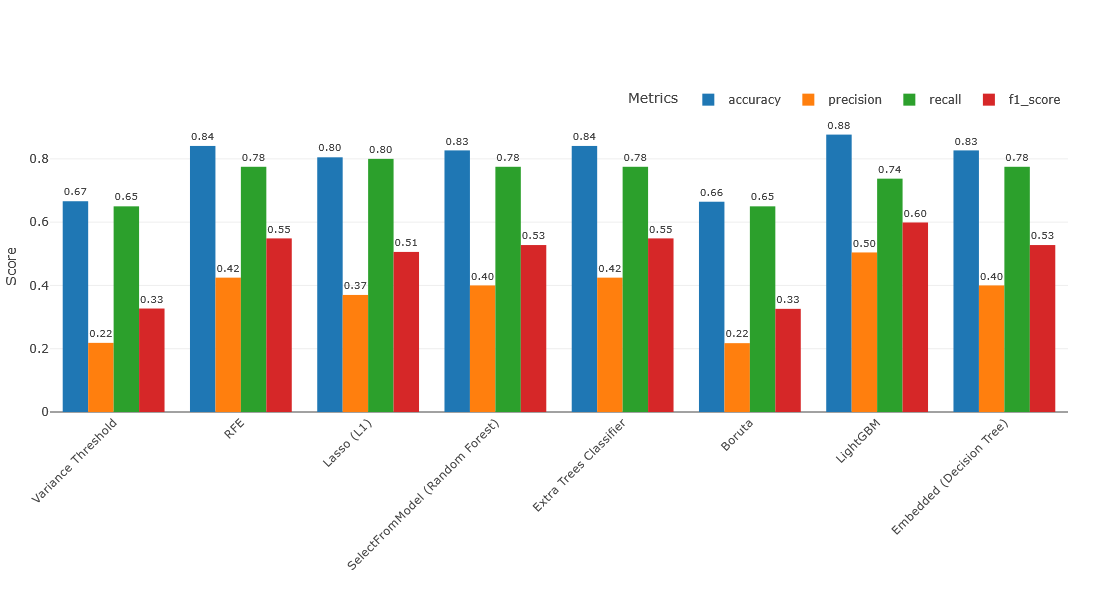

In [79]:
import plotly.express as px
import pandas as pd

# (Assuming results_df has been created earlier)
# results_df = pd.DataFrame(results).T
# results_df = results_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

metrics = ['accuracy', 'precision', 'recall', 'f1_score']

# Transform the DataFrame into a long format suitable for Plotly bar charts
results_melted = results_df.melt(
    id_vars=['Feature Selection Method'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

# Create a grouped bar chart
fig = px.bar(
    results_melted,
    x='Feature Selection Method',
    y='Score',
    color='Metric',
    barmode='group',
    text='Score',
    title='',
    labels={'Score': 'Performance Metric', 'Feature Selection Method': 'Method'},
    height=600
)

# Display the score values on top of each bar
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Apply layout adjustments to prevent labels and legend from being cut off
fig.update_layout(
    legend_title="Metrics",
    xaxis_title="",
    yaxis_title="Score",
    margin=dict(l=50, r=50, t=120, b=180),   # Increased top margin to accommodate the legend
    xaxis=dict(
        tickangle=-45,                      # Rotate labels for better readability
        automargin=True                     # This is valid for xaxis
    ),
    legend=dict(
        orientation='h',                    # Horizontal legend
        yanchor='bottom',
        y=1.02,                             # Position slightly above the chart
        xanchor='right',
        x=1
        # Removed automargin=True (not supported for legend)
    )
)

# Display and save the figure with high resolution
fig.show()
fig.write_image("Images/Comparison of Feature Selection Methods.png", scale=6)

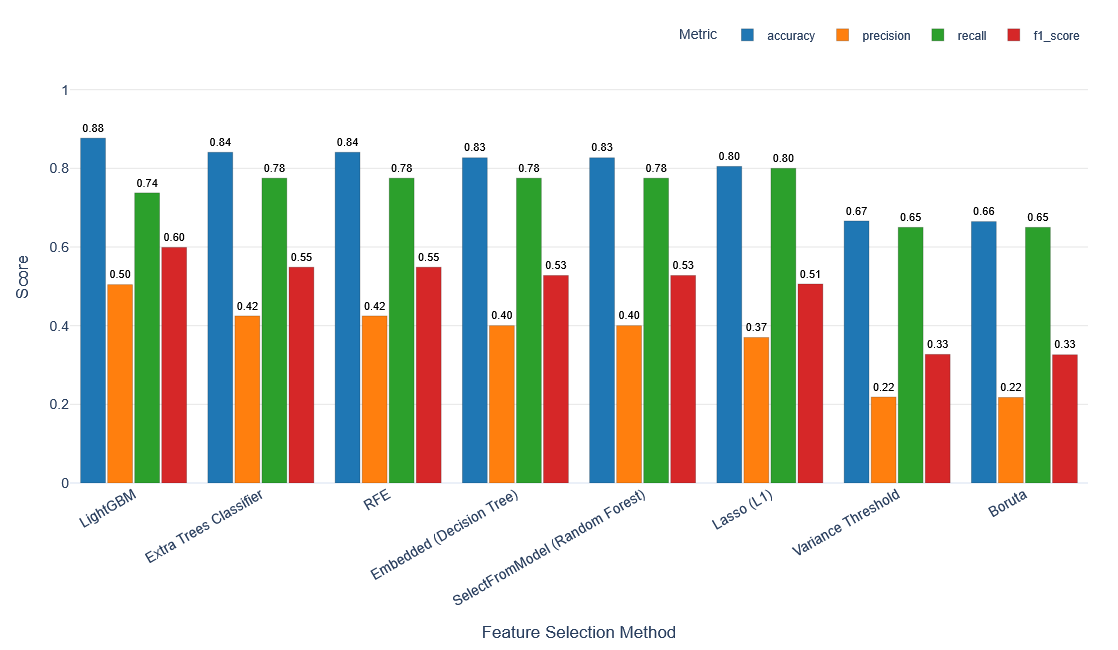

In [80]:
import pandas as pd
import plotly.express as px

metrics = ['accuracy', 'precision', 'recall', 'f1_score']

# Prepare data
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Feature Selection Method'})

results_melted = results_df.melt(
    id_vars=['Feature Selection Method'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

# Order methods by mean performance (best → worst)
method_order = (
    results_melted.groupby('Feature Selection Method')['Score']
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Clean, consistent palette: one color per metric
metric_palette = {
    'accuracy' : "#1f77b4",  # blue
    'precision': "#ff7f0e",  # orange
    'recall'   : "#2ca02c",  # green
    'f1_score' : "#d62728",  # red
}

# Main figure
fig = px.bar(
    results_melted,
    x='Feature Selection Method',
    y='Score',
    color='Metric',
    barmode='group',
    category_orders={'Feature Selection Method': method_order, 'Metric': metrics},
    color_discrete_map=metric_palette,
    labels={'Score': 'Score', 'Feature Selection Method': 'Feature Selection Method'},
    title='',
    template='plotly_white',
    height=650
)

# Bar styling + (optional) value labels
fig.update_traces(
    marker_line_width=0.8,
    marker_line_color='rgba(0,0,0,0.25)',
    texttemplate='%{y:.2f}',
    textposition='outside',
    textfont=dict(size=11, family="Arial", color="black"),
    cliponaxis=False
)

# Layout / typography
fig.update_layout(
    title_x=0.5,
    title_font=dict(size=22, family="Arial"),
    font=dict(size=14, family="Arial"),
    legend_title="Metric",
    legend_font=dict(size=12),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    xaxis_title="Feature Selection Method",
    yaxis_title="Score",
    bargap=0.15,
    bargroupgap=0.08,
    margin=dict(l=70, r=30, t=70, b=130),
    uniformtext_minsize=8,
    uniformtext_mode='hide',  # hide labels if they would overlap
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# Axes
fig.update_yaxes(
    range=[0, 1.05],          # adjust if your scores aren’t in [0, 1]
    showgrid=True,
    gridcolor='rgba(0,0,0,0.1)'
)
fig.update_xaxes(
    tickangle=-30,
    automargin=True
)

fig.show()

fig.write_image(
    "Images/Comparison_of_Feature_Selection_Methods.png",
    width=2200,
    height=1300,
    scale=2
)



In [103]:
importance_df

,Feature Selection Method,TV1,Eating1,Cooking1,Driving1,RBC,FBS,TG,ALP,HDL.C,TEACOFFEE,BAVARAGE,Vegetables,Juice,HasFattyLiver,HasHypertension
0,Variance Threshold,0.022728,0.011077,0.012106,0.054207,0.010265,0.002503,0.003879,0.005174,0.015786,0.020110,0.030843,0.013099,0.053668,0.192351,0.200821
1,RFE,0.022728,0.011077,0.012106,0.054207,0.010265,0.002503,0.003879,0.005174,0.015786,0.020110,0.030843,0.013099,0.053668,0.192351,0.200821
2,Lasso (L1),0.022728,0.011077,0.012106,0.054207,0.010265,0.002503,0.003879,0.005174,0.015786,0.020110,0.030843,0.013099,0.053668,0.192351,0.200821
3,SelectFromModel (Random Forest),0.022728,0.011077,0.012106,0.054207,0.010265,0.002503,0.003879,0.005174,0.015786,0.020110,0.030843,0.013099,0.053668,0.192351,0.200821
4,Extra Trees Classifier,0.032746,0.029271,0.034986,0.030480,0.027947,0.288487,0.037847,0.030800,0.028220,0.032074,0.044536,0.032012,0.032219,0.110066,0.208309
5,Boruta,0.032746,0.029271,0.034986,0.030480,0.027947,0.288487,0.037847,0.030800,0.028220,0.032074,0.044536,0.032012,0.032219,0.110066,0.208309
6,LightGBM,0.032746,0.029271,0.034986,0.030480,0.027947,0.288487,0.037847,0.030800,0.028220,0.032074,0.044536,0.032012,0.032219,0.110066,0.208309
7,Embedded (Decision Tree),0.032746,0.029271,0.034986,0.030480,0.027947,0.288487,0.037847,0.030800,0.028220,0.032074,0.044536,0.032012,0.032219,0.110066,0.208309


In [109]:
importance_df.to_excel("Images/"+"importance_df.xlsx") 

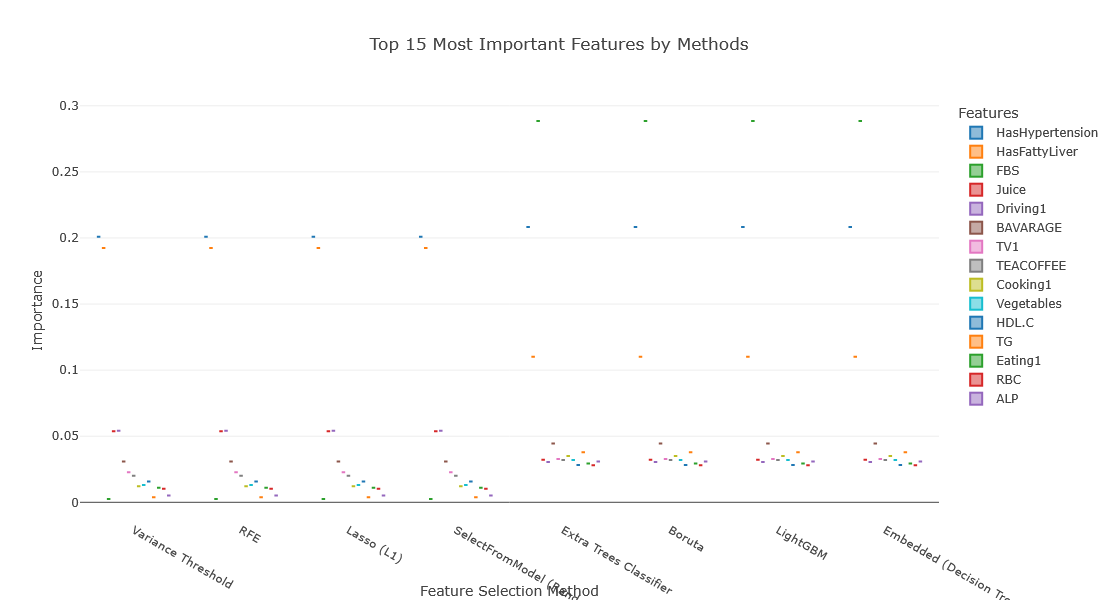

In [82]:
import pandas as pd
import plotly.express as px

# Assuming `X` is your DataFrame with the real feature names (predictors)
# Assuming `feature_importances` is a dictionary where each key is a method, 
# and the value is a pandas Series or DataFrame with feature importance scores.

# Convert the feature importances into a DataFrame for visualization
importance_df = pd.DataFrame(feature_importances).T  # Transpose so that methods are rows
importance_df.columns = X_train.columns  # Use the actual feature names from X
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__','')

importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# Determine the most important predictors (e.g., top N important features)
# Let's say we want to select the top 10 most important features across all methods
top_n = 15  # You can change this number to select more or fewer features

# Aggregate feature importance across all methods by averaging importance scores
importance_avg = importance_df.drop('Feature Selection Method', axis=1).mean(axis=0)

# Get the top N most important features
top_features = importance_avg.nlargest(top_n).index

# Filter the original importance DataFrame to include only the top features
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt the DataFrame for better visualization
importance_melted = importance_top_features_df.melt(id_vars=['Feature Selection Method'], 
                                                    var_name='Feature', 
                                                    value_name='Importance')

# Create a box plot using Plotly to compare feature importance across different methods
fig_importance = px.box(
    importance_melted,
    x='Feature Selection Method',
    y='Importance',
    color='Feature',
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
    height=600
)

# Update plot layout
fig_importance.update_layout(legend_title="Features", 
                             xaxis_title="Feature Selection Method", 
                             yaxis_title="Importance")

# Show the plot
fig_importance.show()
title=str(f'Top {top_n} Most Important Features by Methods0')
fig_importance.write_image(title + ".png", scale=6)

In [106]:
importance_top_features_df
importance_top_features_df.to_excel("Images/"+"importance_df.xlsx")  

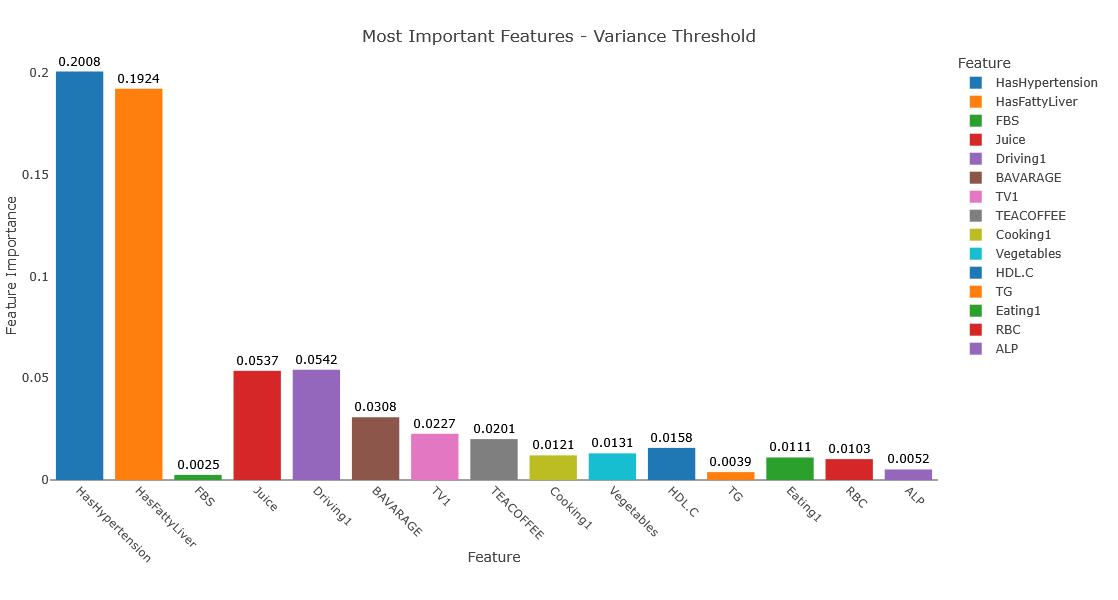

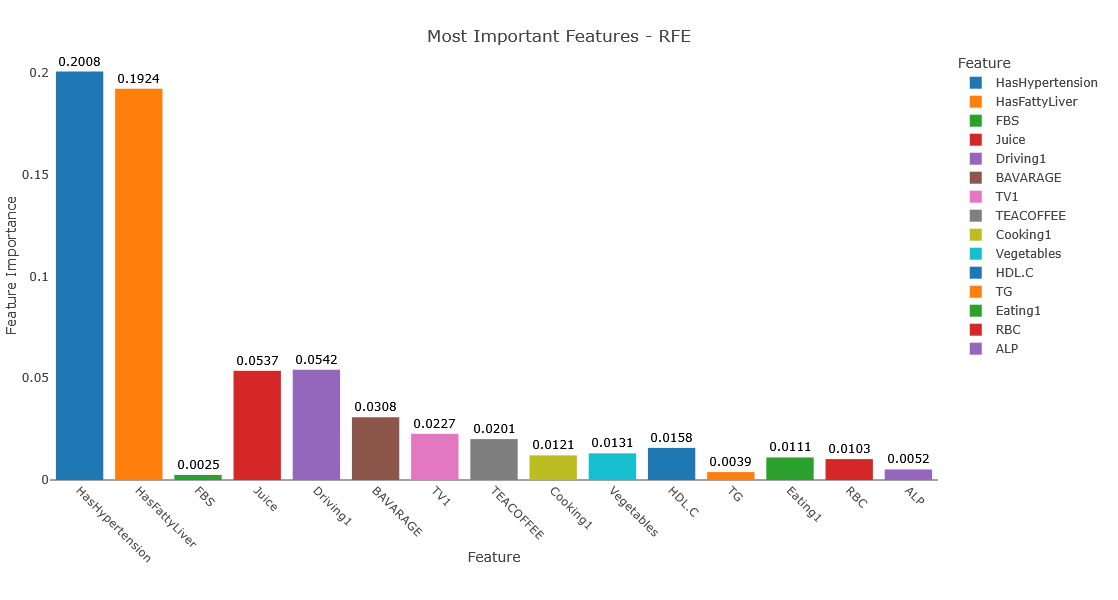

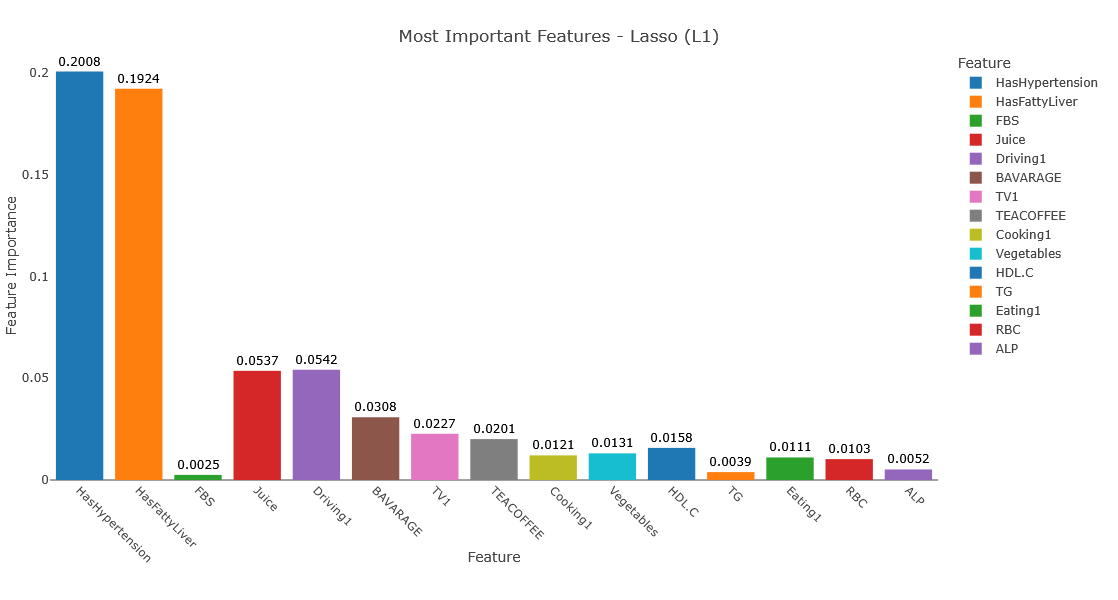

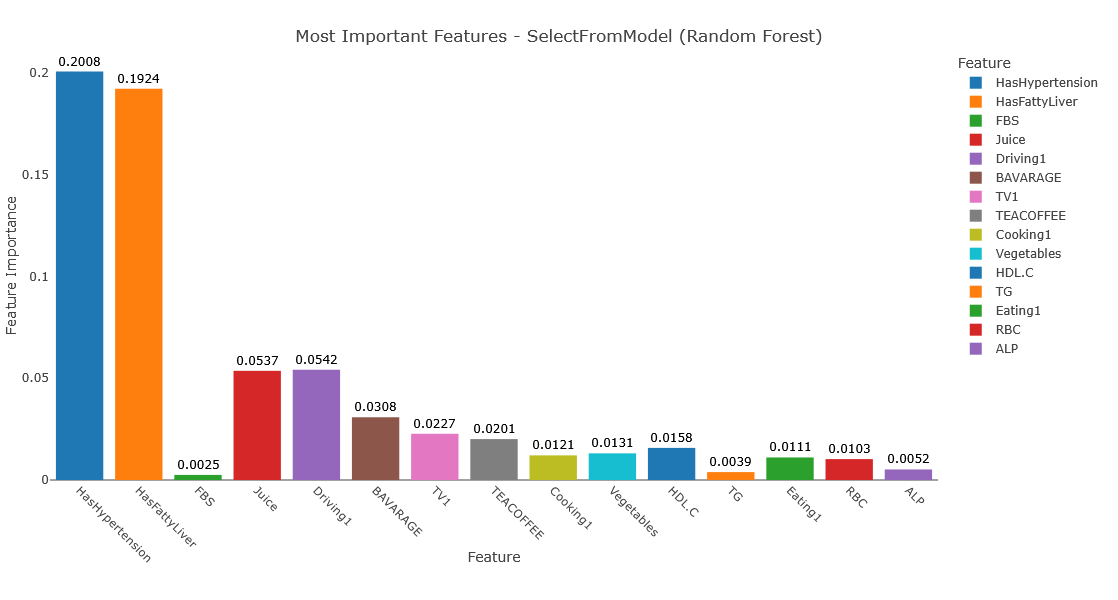

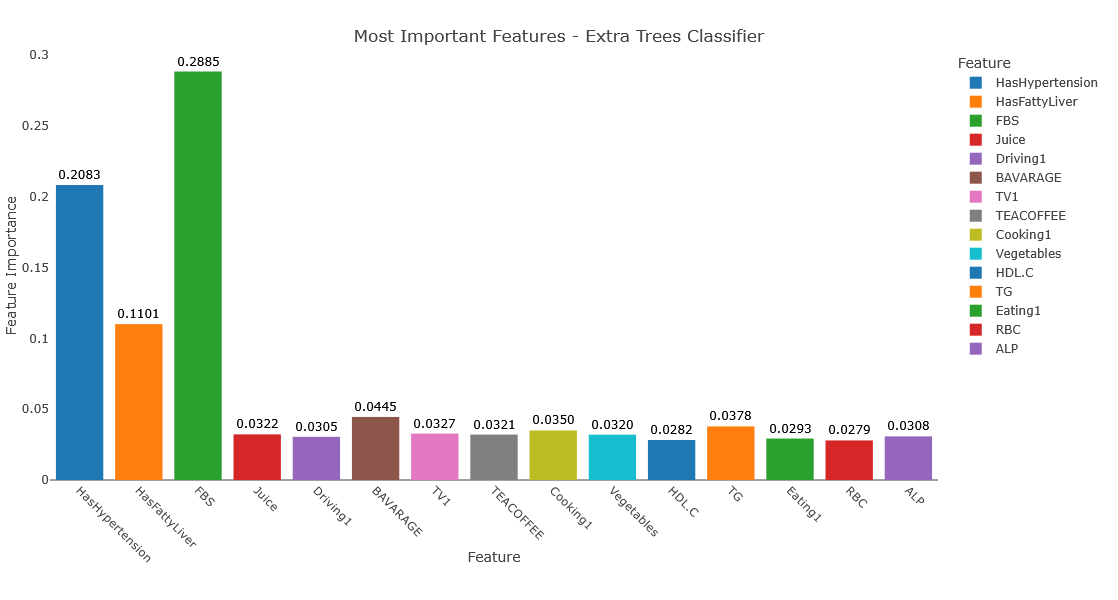

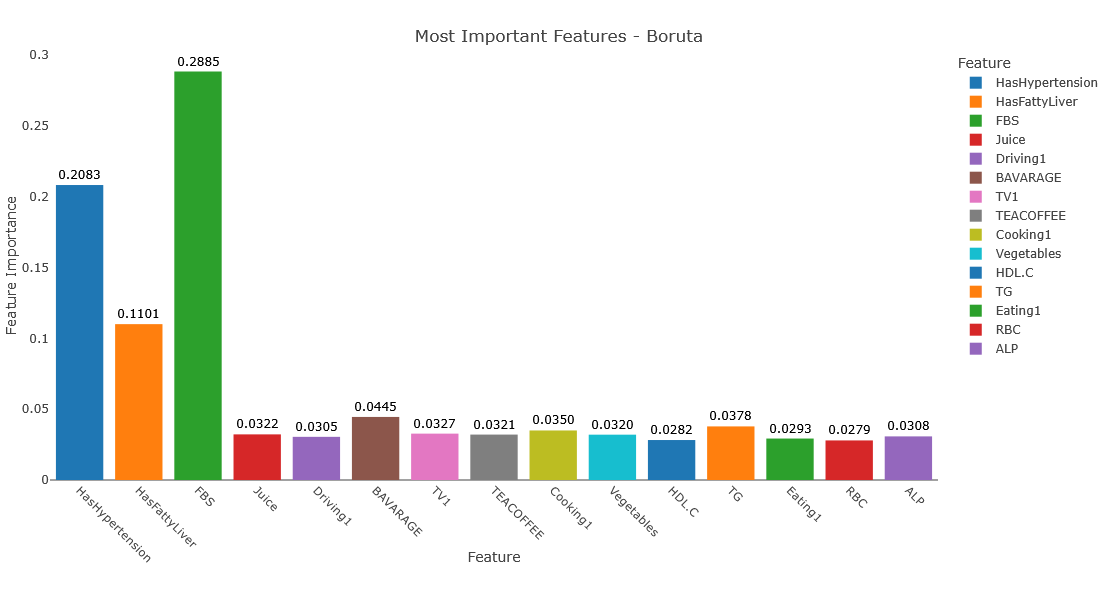

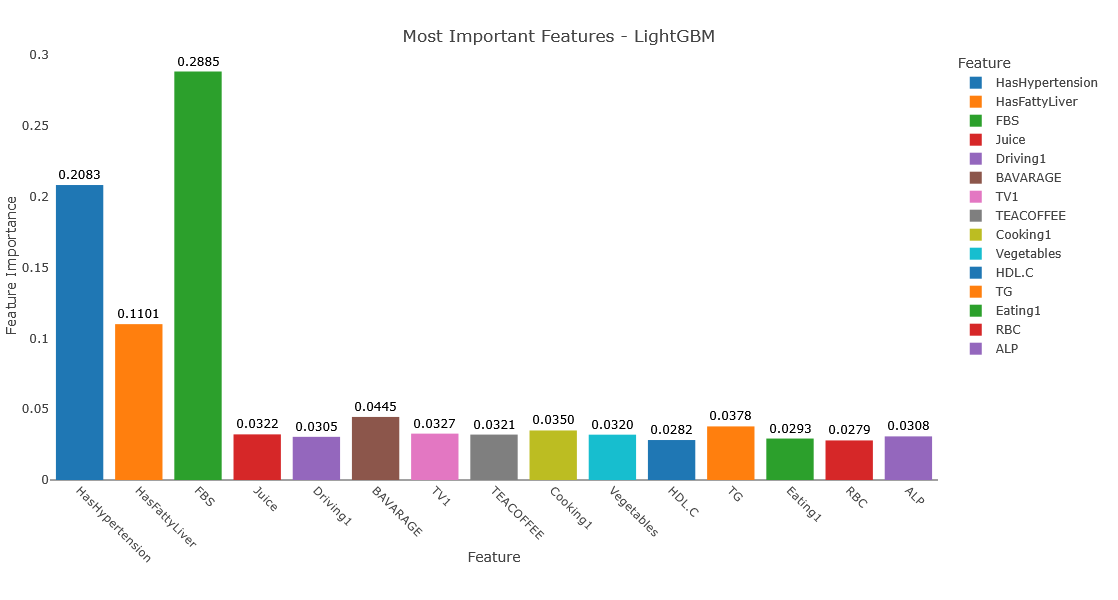

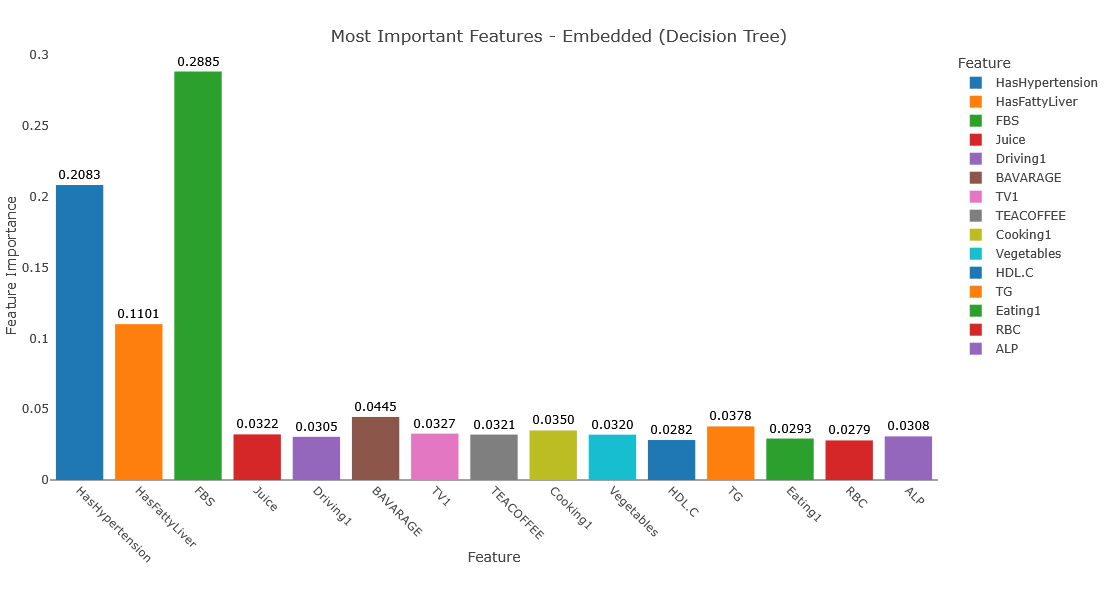

In [101]:
import pandas as pd
import plotly.express as px

# Assuming `X` is your DataFrame with the real feature names (predictors)
# Assuming `feature_importances` is a dictionary where each key is a method, 
# and the value is a pandas Series or DataFrame with feature importance scores.

# Convert the feature importances into a DataFrame for visualization
importance_df = pd.DataFrame(feature_importances).T  # Transpose so that methods are rows
importance_df.columns = X_train.columns  # Use the actual feature names from X
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__','')

importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# Determine the most important predictors (e.g., top N important features)
top_n = 15  # You can change this number to select more or fewer features

# Aggregate feature importance across all methods by averaging importance scores
importance_avg = importance_df.drop('Feature Selection Method', axis=1).mean(axis=0)

# Get the top N most important features based on average importance across methods
top_features = importance_avg.nlargest(top_n).index

# Filter the original importance DataFrame to include only the top features
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt the DataFrame for better visualization
importance_melted = importance_top_features_df.melt(id_vars=['Feature Selection Method'], 
                                                    var_name='Feature', 
                                                    value_name='Importance')

# Generate separate charts for each feature selection method
for method in importance_melted['Feature Selection Method'].unique():
    # Filter the data for the current method
    method_data = importance_melted[importance_melted['Feature Selection Method'] == method]

    # Create a bar plot for the current method
    fig_importance = px.bar(
        method_data,
        x='Feature',
        y='Importance',
        color='Feature',
        title=f'Most Important Features - {method}',
        labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
        height=600,
        category_orders={'Feature': list(top_features)},  # Ensure top features are sorted
        color_continuous_scale='Viridis',  # Use a gradient color scale for visual effect
    )

    # Add annotations for each bar with the importance value
    for i, row in method_data.iterrows():
        fig_importance.add_annotation(
            x=row['Feature'],
            y=row['Importance'],
            text=f"{row['Importance']:.4f}",  # Format to 4 decimal places
            showarrow=False,
            font=dict(size=12, color='black'),
            align="center",
            yanchor="bottom"  # Corrected from "verticalalignment"
        )

    # Update plot layout for better presentation
    fig_importance.update_layout(
        legend_title="Feature",
        xaxis_title="Feature",
        yaxis_title="Feature Importance",
        xaxis={'tickangle': 45, 'showgrid': False},  # Rotate feature labels for readability
        yaxis={'showgrid': True, 'gridcolor': 'rgba(255, 255, 255, 0.3)'},  # Add gridlines
        plot_bgcolor='rgba(0,0,0,0)',  # Make background transparent
        margin=dict(t=50, b=120, l=50, r=50),  # Adjust margins
        title_x=0.5,  # Center the title
        title_y=0.95,  # Move title to top
    )

    # Show the plot for the current method
    fig_importance.show()
    title=str(f'Most Important Features - {method}')
    fig_importance.write_image("Images/"+title + ".png", scale=6)

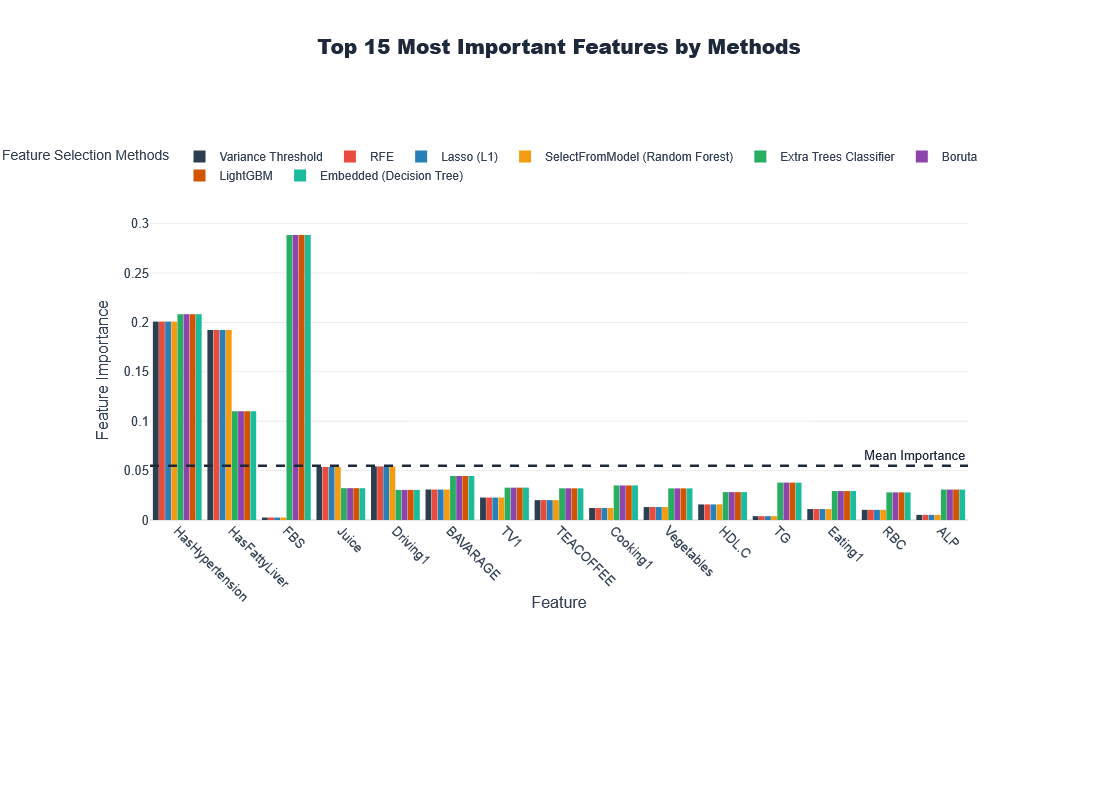

In [94]:
import pandas as pd
import plotly.express as px

# (Assuming X_train and feature_importances are defined earlier)

# Convert the feature importances dictionary into a DataFrame
importance_df = pd.DataFrame(feature_importances).T
importance_df.columns = X_train.columns
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__', '')
importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# Select the top N features based on average importance across all methods
top_n = 15
importance_avg = importance_df.drop('Feature Selection Method', axis=1).mean(axis=0)
top_features = importance_avg.nlargest(top_n).index

# Keep only the top features in the DataFrame
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt the DataFrame for compatibility with Plotly bar charts
importance_melted = importance_top_features_df.melt(
    id_vars=['Feature Selection Method'],
    var_name='Feature',
    value_name='Importance'
)

# ============================================================
# Professional & balanced color palette
# ============================================================
professional_colors = [
    '#2C3E50',  # Dark Navy
    '#E74C3C',  # Brick Red
    '#2980B9',  # Bright Blue
    '#F39C12',  # Golden Orange
    '#27AE60',  # Emerald Green
    '#8E44AD',  # Royal Purple
    '#D35400',  # Burnt Orange
    '#1ABC9C'   # Turquoise
]

# ============================================================
# Create the bar chart (data labels removed)
# ============================================================
fig_importance = px.bar(
    importance_melted,
    x='Feature',
    y='Importance',
    color='Feature Selection Method',
    color_discrete_sequence=professional_colors,
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
    height=800,
    width=1200,
    barmode='group',
    category_orders={'Feature': list(top_features)}
)

# ============================================================
# CRITICAL FIX: Increase margins and enable automargin for x-axis
# ============================================================
fig_importance.update_layout(
    legend_title="Feature Selection Methods",
    xaxis_title="Feature",
    yaxis_title="Feature Importance",
    xaxis={
        'tickangle': 45,
        'showgrid': False,
        'zeroline': False,
        'automargin': True   # <-- Auto-adjusts left/right margins to fit long labels
    },
    yaxis={
        'showgrid': True,
        'gridcolor': 'rgba(0,0,0,0.08)',
        'zeroline': True,
        'zerolinecolor': 'rgba(0,0,0,0.2)'
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    
    # ============================================================
    # SIGNIFICANTLY INCREASED MARGINS TO PREVENT CLIPPING
    # ============================================================
    margin=dict(
        l=150,   # Left margin (for y-axis labels)
        r=150,   # Right margin (for legend if it goes off)
        t=220,   # Top margin (for title, legend, and horizontal line annotation)
        b=280    # Bottom margin (for rotated x-axis labels)
    ),
    
    title_x=0.5,
    title_y=0.95,
    title_font=dict(size=20, family="Arial Black", color="#1e293b"),
    font=dict(family="Arial, sans-serif", size=13, color="#334155"),
    
    # Legend: horizontal, placed above the plot but with enough top space
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.10,          # Slightly higher to avoid overlapping with title
        xanchor='right',
        x=1,
        font=dict(size=12)
    ),
    bargap=0.1,
    bargroupgap=0.05
)

# Add a horizontal line for mean importance
fig_importance.add_hline(
    y=importance_melted['Importance'].mean(),
    line=dict(color='#1e293b', dash='dash', width=2.5),
    annotation_text='Mean Importance',
    annotation_position='top right',
    annotation_font_size=13,
    annotation_font_color='#1e293b'
)

# Display and save the figure
fig_importance.show()
title = f"Top {top_n} Most Important Features by Methods"
fig_importance.write_image(f"Images/{title}.png", scale=6)

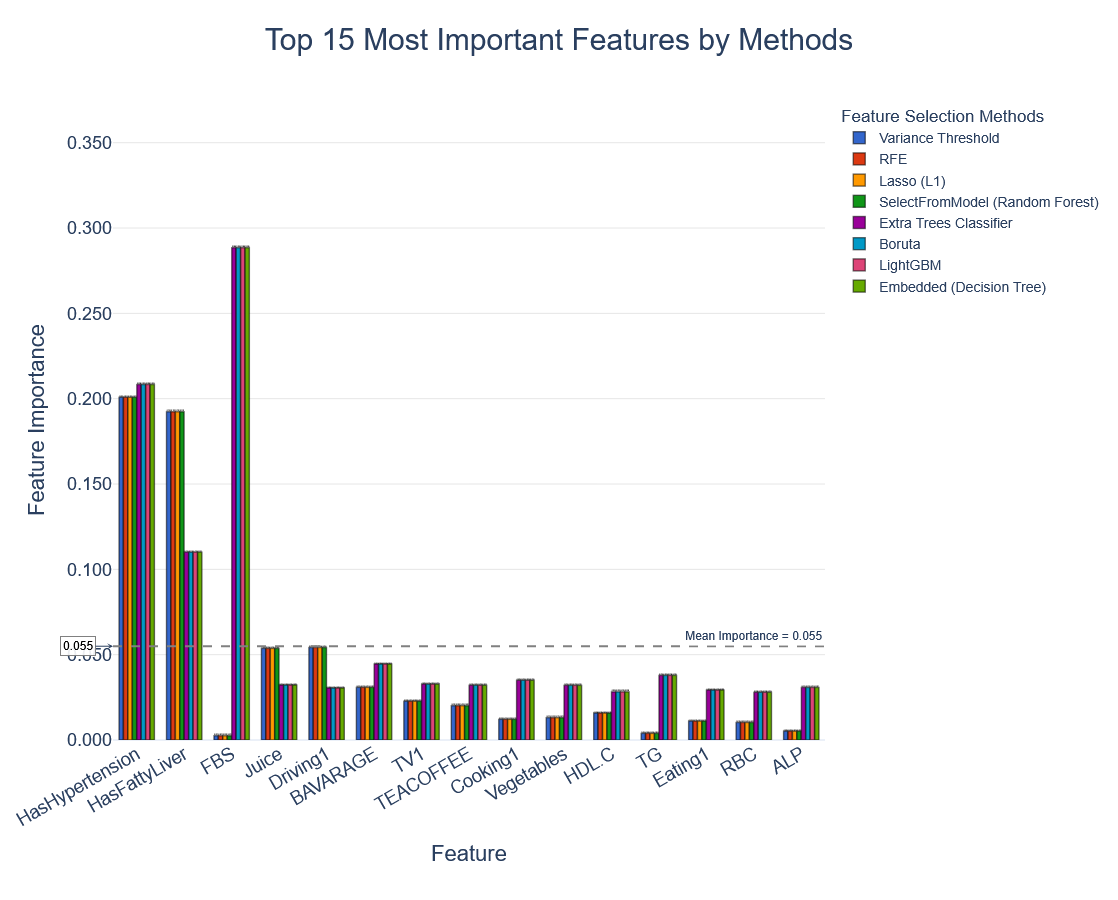

In [95]:
# — High-quality grouped bar chart of top feature importances (clean, sharp, readable) —
import re
import pandas as pd
import plotly.express as px

# ---------- Inputs ----------
# feature_importances: dict like {"Method A": pd.Series, "Method B": pd.Series, ...}
# X_train: your DataFrame of predictors with real feature names
top_n = 15  # number of features to display

# ---------- Build tidy DataFrame (robust to dtypes/prefixes) ----------
importance_df = pd.DataFrame(feature_importances).T  # rows = methods, cols = features
try:
    importance_df.columns = X_train.columns
except Exception:
    pass

# optional: strip pipeline prefixes
importance_df.columns = (
    pd.Index(importance_df.columns.astype(str))
      .str.replace(r'^num_imputer__', '', regex=True)
)

# ensure numeric
importance_df = importance_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# bring method name out of index
importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# ---------- Select Top-N features by mean importance ----------
importance_avg = importance_df.drop(columns=['Feature Selection Method']).mean(axis=0)
top_features = importance_avg.nlargest(top_n).index.tolist()

# tidy (long) for Plotly
importance_top = importance_df[['Feature Selection Method'] + top_features]
importance_melted = importance_top.melt(
    id_vars=['Feature Selection Method'],
    var_name='Feature',
    value_name='Importance'
)

# ---------- Figure (modern bright palette, grouped) ----------
bright_palette = [
    "#3366CC", "#DC3912", "#FF9900", "#109618",
    "#990099", "#0099C6", "#DD4477", "#66AA00"
]
methods = importance_melted['Feature Selection Method'].unique()
palette = (bright_palette * (len(methods)//len(bright_palette) + 1))[:len(methods)]

fig_importance = px.bar(
    importance_melted,
    x='Feature',
    y='Importance',
    color='Feature Selection Method',
    category_orders={'Feature': top_features},
    color_discrete_sequence=palette,
    barmode='group',
    text='Importance',  # we'll format below
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
    height=900,
    template='plotly_white'
)

# ---------- Make it crisp: thicker bars, readable labels, clean lines ----------
fig_importance.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside',
    textfont=dict(size=12, color="black"),
    marker_line_width=1.4,
    marker_line_color='rgba(0,0,0,0.55)',
    cliponaxis=False
)

ymax = float(importance_melted['Importance'].max() or 1.0)
fig_importance.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    font=dict(size=18, family="Arial, Liberation Sans, DejaVu Sans, sans-serif"),
    title_font=dict(size=30),
    legend_title_text="Feature Selection Methods",
    legend_font=dict(size=14),
    # put legend on the right (neat when many methods)
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    xaxis_title="Feature",
    yaxis_title="Feature Importance",
    bargap=0.25,        # more space between feature groups
    bargroupgap=0.05,   # slight space within each group
    margin=dict(l=90, r=220, t=100, b=160),
    paper_bgcolor='white',
    plot_bgcolor='white'
)
fig_importance.update_xaxes(tickangle=-30, automargin=True, showgrid=False)
fig_importance.update_yaxes(range=[0, ymax * 1.30], tickformat=".3f", gridcolor='rgba(0,0,0,0.10)')

# ---------- Mean importance line with numeric value (annotation + y-axis marker) ----------
mean_val = float(importance_melted['Importance'].mean())
fig_importance.add_hline(
    y=mean_val,
    line=dict(color='gray', dash='dash', width=2),
    annotation_text=f"Mean Importance = {mean_val:.3f}",
    annotation_position='top right',
    annotation_font_size=12,
    annotation_bgcolor="rgba(255,255,255,0.85)"
)
fig_importance.add_annotation(
    xref="paper", x=0.0, yref="y", y=mean_val,
    text=f"{mean_val:.3f}", showarrow=True, arrowhead=3,
    ax=-35, ay=0, bgcolor="rgba(255,255,255,0.9)",
    bordercolor="gray", font=dict(size=12, color="black")
)

# ---------- Show & export (hi-res PNG + vector SVG) ----------
fig_importance.show()

export_title = f"Top_{top_n}_Most_Important_Features_by_Methods"
# requires: pip install -U kaleido
fig_importance.write_image(f"Images/{export_title}.svg", width=2400, height=1300, scale=1)   # vector
fig_importance.write_image(f"Images/{export_title}.png", width=3600, height=1800, scale=1)   # hi-res


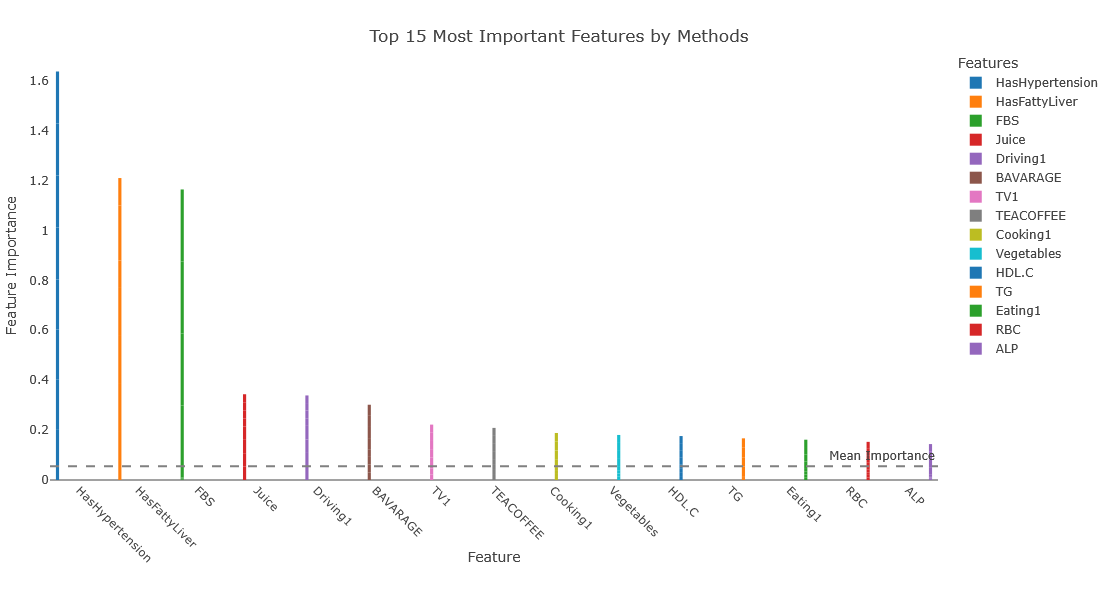

In [96]:
import pandas as pd
import plotly.express as px

# Assuming `X` is your DataFrame with the real feature names (predictors)
# Assuming `feature_importances` is a dictionary where each key is a method, 
# and the value is a pandas Series or DataFrame with feature importance scores.

# Convert the feature importances into a DataFrame for visualization
importance_df = pd.DataFrame(feature_importances).T  # Transpose so that methods are rows
importance_df.columns = X_train.columns  # Use the actual feature names from X
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__','')

importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# Determine the most important predictors (e.g., top N important features)
top_n = 15  # You can change this number to select more or fewer features

# Aggregate feature importance across all methods by averaging importance scores
importance_avg = importance_df.drop('Feature Selection Method', axis=1).mean(axis=0)

# Get the top N most important features
top_features = importance_avg.nlargest(top_n).index

# Filter the original importance DataFrame to include only the top features
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt the DataFrame for better visualization
importance_melted = importance_top_features_df.melt(id_vars=['Feature Selection Method'], 
                                                    var_name='Feature', 
                                                    value_name='Importance')

# Create a bar plot using Plotly to compare feature importance across different methods
fig_importance = px.bar(
    importance_melted,
    x='Feature',
    y='Importance',
    color='Feature',  # Color bars by Feature to match the legend
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
    height=600,
    barmode='group',  # Group bars for comparison
    category_orders={'Feature': list(top_features)},  # Ensure top features are sorted
)

# Update plot layout for better presentation
fig_importance.update_layout(
    legend_title="Features",  # Legend title to "Features"
    xaxis_title="Feature", 
    yaxis_title="Feature Importance",
    xaxis={'tickangle': 45, 'showgrid': False},  # Rotate feature labels for readability
    yaxis={'showgrid': True, 'gridcolor': 'rgba(255, 255, 255, 0.3)'},  # Add a grid for better readability
    plot_bgcolor='rgba(0,0,0,0)',  # Make background transparent
    margin=dict(t=50, b=120, l=50, r=50),  # Adjust margins to prevent clipping of labels
    title_x=0.5,  # Center the title
    title_y=0.95,  # Move the title to the top
)

# Add horizontal line at mean importance level across all methods for reference
fig_importance.add_hline(
    y=importance_melted['Importance'].mean(), 
    line=dict(color='gray', dash='dash', width=2), 
    annotation_text='Mean Importance', 
    annotation_position='top right', 
    annotation_font_size=12
)

# Show the plot
fig_importance.show()
title=str(f"Top {top_n} Most Important Features by Methods2")
fig_importance.write_image("Images/"+title + ".png", scale=6)

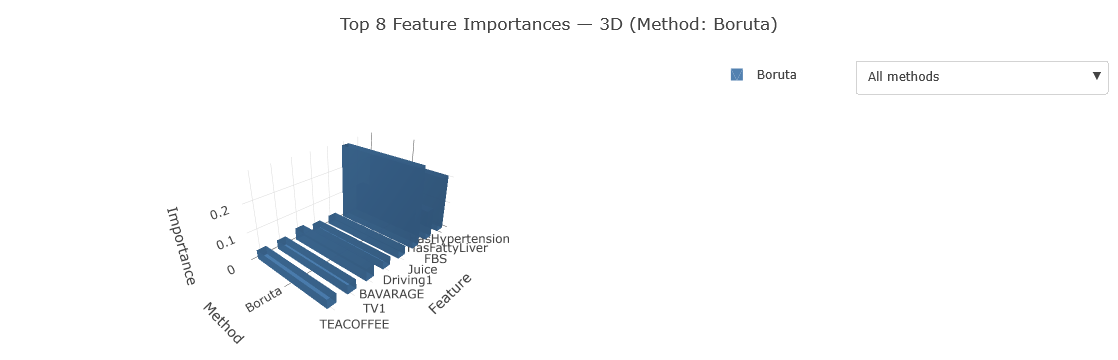

In [97]:
# --- Cleaner 3D Bar Chart (less busy): dropdown to switch methods, slimmer bars, top-8 features ---
import re, os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ---------------- Inputs ----------------
top_n_features_default = 8    # fewer features to reduce clutter (adjust as needed)
out_dir = "Images"
os.makedirs(out_dir, exist_ok=True)

# ---------------- Prep: tidy & robust ----------------
importance_df = pd.DataFrame(feature_importances).T  # rows=methods, cols=features

# Align to your feature names when possible
try:
    importance_df.columns = X_train.columns
except Exception:
    pass

# Clean pipeline prefixes; ensure numeric
importance_df.columns = (
    pd.Index(importance_df.columns.astype(str))
      .str.replace(r'^num_imputer__', '', regex=True)
)
importance_df = importance_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# Bring method name out of index
importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# ---------------- Select top-N features (by mean across methods) ----------------
importance_avg = importance_df.drop(columns=['Feature Selection Method']).mean(axis=0)
top_features = importance_avg.nlargest(top_n_features_default).index.tolist()

# Long format
long_df = importance_df[['Feature Selection Method'] + top_features].melt(
    id_vars=['Feature Selection Method'],
    var_name='Feature',
    value_name='Importance'
)

# Stable orders
feature_order = top_features
method_order = (
    long_df.groupby('Feature Selection Method')['Importance']
    .mean().sort_values(ascending=False).index.tolist()
)

# Map categories → numeric grid positions
feat_to_x = {f: i for i, f in enumerate(feature_order)}
meth_to_y = {m: j for j, m in enumerate(method_order)}
long_df['x_idx'] = long_df['Feature'].map(feat_to_x)
long_df['y_idx'] = long_df['Feature Selection Method'].map(meth_to_y)

# ---------------- Palette (subtle, modern) ----------------
palette = [
    "#4477AA","#EE6677","#228833","#CCBB44","#66CCEE","#AA3377","#BBBBBB",
    "#3366CC","#B82E2E"
]
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(method_order)}

# ---------------- 3D bars via Mesh3d ----------------
def cuboid_vertices(xc, yc, dz, dx=0.45, dy=0.45):
    hx, hy = dx/2.0, dy/2.0
    z0, z1 = 0.0, float(dz)
    return [
        (xc - hx, yc - hy, z0), (xc + hx, yc - hy, z0),
        (xc + hx, yc + hy, z0), (xc - hx, yc + hy, z0),
        (xc - hx, yc - hy, z1), (xc + hx, yc - hy, z1),
        (xc + hx, yc + hy, z1), (xc - hx, yc + hy, z1),
    ]

CUBOID_TRIS = [
    (0,1,2),(0,2,3),
    (4,5,6),(4,6,7),
    (0,1,5),(0,5,4),
    (1,2,6),(1,6,5),
    (2,3,7),(2,7,6),
    (3,0,4),(3,4,7)
]

def make_method_mesh(method_name, subdf, color, dx=0.45, dy=0.45):
    xs, ys, zs, I, J, K = [], [], [], [], [], []
    vcount = 0
    for _, row in subdf.iterrows():
        dz = float(row['Importance'])
        if dz <= 0:
            continue
        verts = cuboid_vertices(row['x_idx'], row['y_idx'], dz, dx=dx, dy=dy)
        for (vx, vy, vz) in verts:
            xs.append(vx); ys.append(vy); zs.append(vz)
        for (i, j, k) in CUBOID_TRIS:
            I.append(vcount + i); J.append(vcount + j); K.append(vcount + k)
        vcount += 8
    return go.Mesh3d(
        x=xs, y=ys, z=zs, i=I, j=J, k=K,
        color=color, opacity=0.92, flatshading=True,
        name=method_name, showlegend=True, hoverinfo="skip"
    )

# Build figure with one Mesh3d + one hover Scatter3d per method
fig = go.Figure()
mesh_traces = []
hover_traces = []

for method in method_order:
    sub = long_df[long_df['Feature Selection Method'] == method]
    mesh = make_method_mesh(method, sub, method_colors[method], dx=0.45, dy=0.45)
    fig.add_trace(mesh); mesh_traces.append(mesh)

    # hover markers (clean tooltips)
    hover_x, hover_y, hover_z, hover_text = [], [], [], []
    for _, r in sub.iterrows():
        if r['Importance'] <= 0:
            continue
        hover_x.append(r['x_idx']); hover_y.append(r['y_idx']); hover_z.append(float(r['Importance']))
        hover_text.append(
            f"<b>Feature</b>: {r['Feature']}<br>"
            f"<b>Method</b>: {r['Feature Selection Method']}<br>"
            f"<b>Importance</b>: {r['Importance']:.3f}"
        )
    hover = go.Scatter3d(
        x=hover_x, y=hover_y, z=hover_z,
        mode='markers',
        marker=dict(size=2, color='rgba(0,0,0,0)'),
        hovertext=hover_text,
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
        name=f"{method} (hover)"
    )
    fig.add_trace(hover); hover_traces.append(hover)

# ---------------- Dropdown to switch methods (default = first method) ----------------
# Build visibility masks: two traces per method (mesh+hover)
n_methods = len(method_order)
n_traces = 2 * n_methods
def vis_for_index(idx):  # show only method idx
    vis = [False] * n_traces
    vis[2*idx] = True
    vis[2*idx + 1] = True
    return vis

buttons = []
for i, method in enumerate(method_order):
    buttons.append(dict(
        label=method,
        method="update",
        args=[{"visible": vis_for_index(i)},
              {"title": f"Top {top_n_features_default} Feature Importances — 3D (Method: {method})"}]
    ))

# Add an "All" button (can be busy; still available)
buttons.insert(0, dict(
    label="All methods",
    method="update",
    args=[{"visible": [True]*n_traces},
          {"title": f"Top {top_n_features_default} Feature Importances — 3D (All Methods)"}]
))

# Initial visibility = first method only
initial_vis = vis_for_index(0)
for t, v in zip(fig.data, initial_vis):
    t.visible = v

fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        x=1.22, xanchor="left",
        y=1.0, yanchor="top",
        buttons=buttons,
        bgcolor="white",
        bordercolor="lightgray",
        font=dict(size=12)
    )]
)

# ---------------- Scene / layout (decluttered) ----------------
fig.update_layout(
    title=f"Top {top_n_features_default} Feature Importances — 3D (Method: {method_order[0]})",
    title_x=0.5,
    scene=dict(
        xaxis=dict(
            title="Feature",
            tickvals=list(range(len(feature_order))),
            ticktext=feature_order,
            gridcolor="rgba(0,0,0,0.15)",
            backgroundcolor="white",
            tickangle=0
        ),
        yaxis=dict(
            title="Method",
            tickvals=list(range(len(method_order))),
            ticktext=method_order,
            gridcolor="rgba(0,0,0,0.15)",
            backgroundcolor="white",
        ),
        zaxis=dict(
            title="Importance",
            gridcolor="rgba(0,0,0,0.15)",
            backgroundcolor="white"
        ),
        camera=dict(eye=dict(x=1.7, y=1.6, z=1.2)),
        aspectmode="manual",
        aspectratio=dict(x=1.4, y=0.8, z=0.7)  # slightly flatter in Y to reduce clutter
    ),
    legend=dict(orientation="v", yanchor="top", y=1.0, xanchor="left", x=1.02),
    margin=dict(l=10, r=260, t=60, b=10),
)

# Softer lighting for less visual noise
fig.update_traces(
    lighting=dict(ambient=0.55, diffuse=0.55, specular=0.2),
    lightposition=dict(x=120, y=160, z=240),
    selector=dict(type='mesh3d')
)

fig.show()

# Optional export
safe_title = f"Top_{top_n_features_default}_Feature_Importances_3D_Clean"
fig.write_html(os.path.join(out_dir, f"{safe_title}.html"), include_plotlyjs="cdn")
# fig.write_image(os.path.join(out_dir, f"{safe_title}.png"), width=1800, height=1200, scale=1)


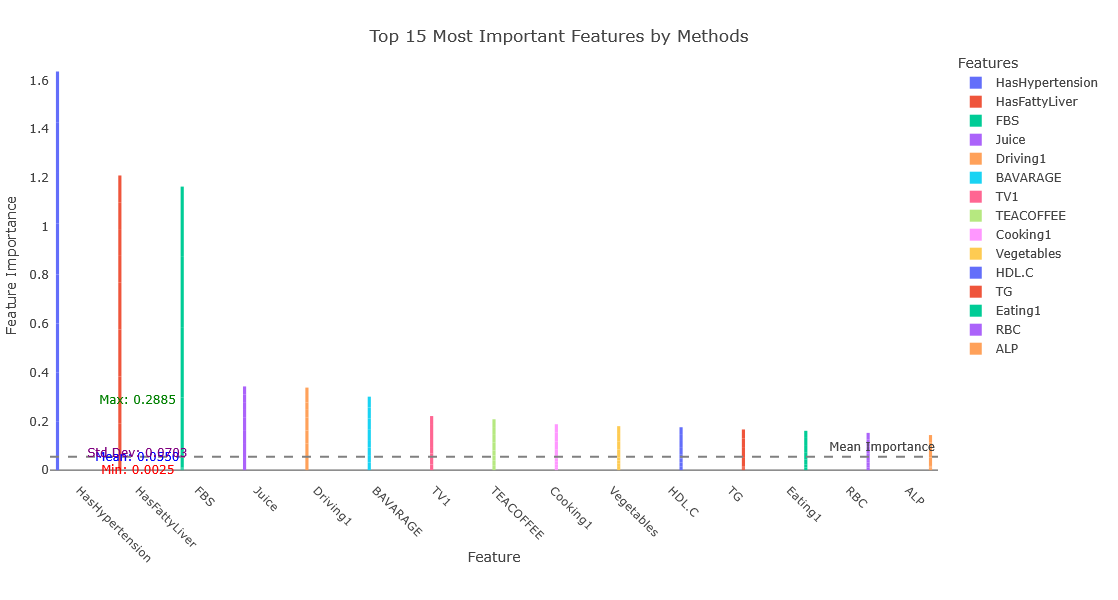

In [98]:
import pandas as pd
import plotly.express as px

# Assuming `X` is your DataFrame with the real feature names (predictors)
# Assuming `feature_importances` is a dictionary where each key is a method, 
# and the value is a pandas Series or DataFrame with feature importance scores.

# Convert the feature importances into a DataFrame for visualization
importance_df = pd.DataFrame(feature_importances).T  # Transpose so that methods are rows
importance_df.columns = X_train.columns  # Use the actual feature names from X
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__','')
importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# Determine the most important predictors (e.g., top N important features)
top_n = 15  # You can change this number to select more or fewer features

# Aggregate feature importance across all methods by averaging importance scores
importance_avg = importance_df.drop('Feature Selection Method', axis=1).mean(axis=0)

# Get the top N most important features
top_features = importance_avg.nlargest(top_n).index

# Filter the original importance DataFrame to include only the top features
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt the DataFrame for better visualization
importance_melted = importance_top_features_df.melt(id_vars=['Feature Selection Method'], 
                                                    var_name='Feature', 
                                                    value_name='Importance')

# Create a bar plot using Plotly to compare feature importance across different methods
fig_importance = px.bar(
    importance_melted,
    x='Feature',
    y='Importance',
    color='Feature',  # Color bars by Feature for clarity
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance', 'Feature Selection Method': 'Method'},
    height=600,
    barmode='group',  # Group bars for comparison
    category_orders={'Feature': list(top_features)},  # Ensure top features are sorted
    color_discrete_sequence=px.colors.qualitative.Plotly,  # Distinct colors for better clarity
    hover_data={'Importance': True, 'Feature': True},  # Add hover data for importance values
)

# Update plot layout for better presentation
fig_importance.update_layout(
    legend_title="Features",  # Legend title to "Features"
    xaxis_title="Feature", 
    yaxis_title="Feature Importance",
    xaxis={'tickangle': 45, 'showgrid': False},  # Rotate feature labels for readability
    yaxis={'showgrid': True, 'gridcolor': 'rgba(255, 255, 255, 0.3)'},  # Add a grid for better readability
    plot_bgcolor='rgba(0,0,0,0)',  # Make background transparent
    margin=dict(t=50, b=120, l=50, r=50),  # Adjust margins to prevent clipping of labels
    title_x=0.5,  # Center the title
    title_y=0.95,  # Move the title to the top
)

# Add horizontal line at mean importance level across all methods for reference
fig_importance.add_hline(
    y=importance_melted['Importance'].mean(), 
    line=dict(color='gray', dash='dash', width=2), 
    annotation_text='Mean Importance', 
    annotation_position='top right', 
    annotation_font_size=12
)

# Additional statistics: Add annotations for max, min, and standard deviation
mean_importance = importance_melted['Importance'].mean()
max_importance = importance_melted['Importance'].max()
min_importance = importance_melted['Importance'].min()
std_importance = importance_melted['Importance'].std()

# Annotate mean, max, min, and std on the plot
fig_importance.add_annotation(
    x=0.98, 
    y=mean_importance, 
    text=f"Mean: {mean_importance:.4f}",
    showarrow=False, 
    font=dict(size=12, color='blue'),
    align="right"
)

fig_importance.add_annotation(
    x=0.98, 
    y=max_importance, 
    text=f"Max: {max_importance:.4f}",
    showarrow=False, 
    font=dict(size=12, color='green'),
    align="right"
)

fig_importance.add_annotation(
    x=0.98, 
    y=min_importance, 
    text=f"Min: {min_importance:.4f}",
    showarrow=False, 
    font=dict(size=12, color='red'),
    align="right"
)

fig_importance.add_annotation(
    x=0.98, 
    y=std_importance, 
    text=f"Std Dev: {std_importance:.4f}",
    showarrow=False, 
    font=dict(size=12, color='purple'),
    align="right"
)

# Show the plot
fig_importance.show()
title=str(f"Top {top_n} Most Important Features by MethodsWithMSTD")
fig_importance.write_image("Images/"+title + ".png", scale=6)


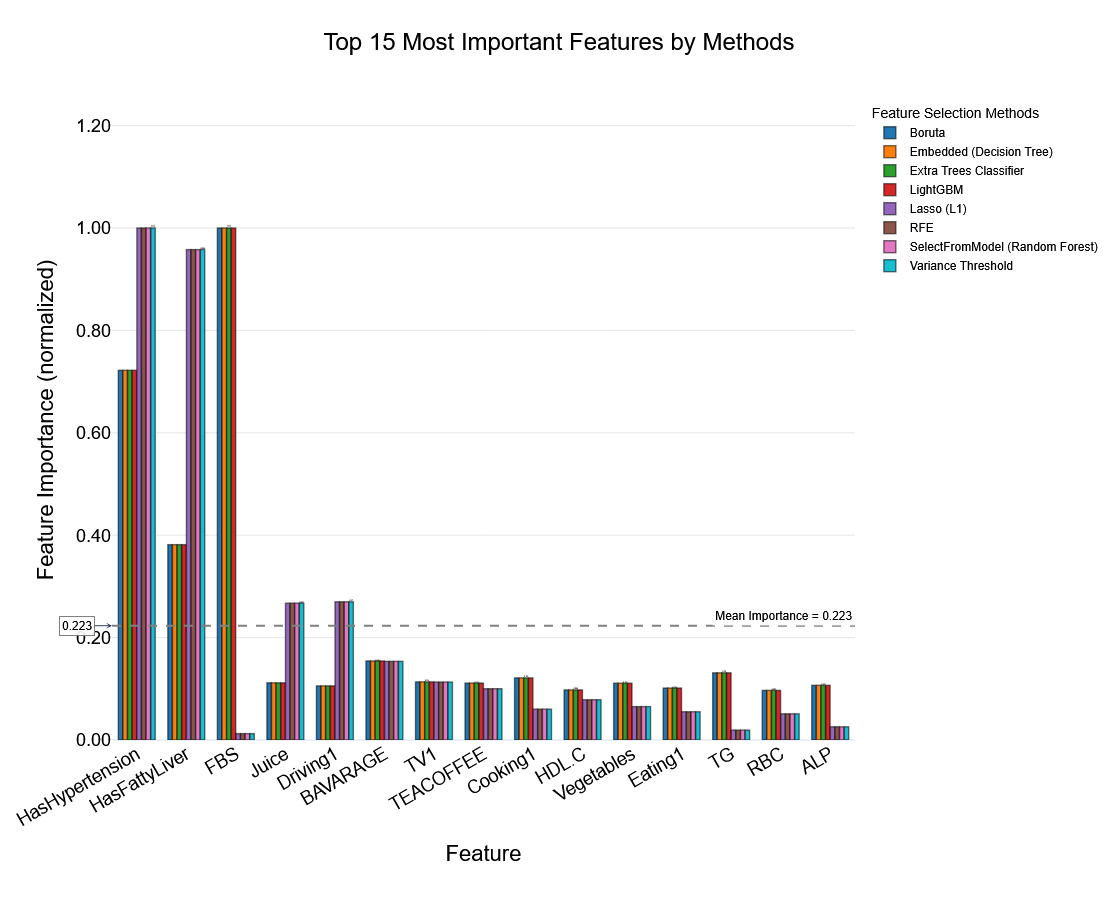

In [99]:
# --- Final: Normalized, Top-N-by-SUM, labels only on TOP bar per feature, mean line/value ---
import re
import numpy as np
import pandas as pd
import plotly.express as px

# ---------------- Inputs ----------------
# feature_importances: dict {"Method A": pd.Series, "Method B": pd.Series, ...}
# X_train: your training DataFrame with original feature names
top_n = 15  # number of features to display

# ------------- Build tidy DataFrame -------------
importance_df = pd.DataFrame(feature_importances).T

# Use actual feature names if available
try:
    importance_df.columns = X_train.columns
except Exception:
    pass

# Clean pipeline prefixes
def clean_name(c):
    return re.sub(r'^num_imputer__', '', str(c))

importance_df.columns = [clean_name(c) for c in importance_df.columns]

# Ensure numeric + fill NaN
importance_df = importance_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# Bring method names into a column
importance_df = importance_df.reset_index().rename(columns={'index': 'Feature Selection Method'})

# ------------- Normalize per method (row) to [0, 1] -------------
numeric_cols = importance_df.columns.difference(['Feature Selection Method'])
row_max = importance_df[numeric_cols].max(axis=1).replace(0, np.nan)
importance_df[numeric_cols] = importance_df[numeric_cols].div(row_max, axis=0).fillna(0.0)

# ------------- Pick Top-N features by SUM across methods -------------
importance_sum = importance_df[numeric_cols].sum(axis=0)
top_features = importance_sum.nlargest(top_n).index.tolist()

# Filter to Top-N
importance_top = importance_df[['Feature Selection Method'] + top_features]

# Long format
importance_melted = importance_top.melt(
    id_vars=['Feature Selection Method'],
    var_name='Feature',
    value_name='Importance'
)

# Orders
feature_order = top_features
method_order = (
    importance_melted.groupby('Feature Selection Method')['Importance']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# ------------- Palette (Tol Vibrant) -------------
tol_vibrant = [
    "#1F77B4",  # deep blue
    "#FF7F0E",  # vivid orange
    "#2CA02C",  # fresh green
    "#D62728",  # bold red
    "#9467BD",  # purple
    "#8C564B",  # brown
    "#E377C2",  # pink
    "#17BECF"   # turquoise
]
unique_methods = importance_melted['Feature Selection Method'].unique()
palette = (tol_vibrant * (len(unique_methods) // len(tol_vibrant) + 1))[:len(unique_methods)]

# ------------- Labels only on the highest bar per feature -------------
idx_max = importance_melted.groupby("Feature")["Importance"].idxmax()
importance_melted["Label"] = ""
importance_melted.loc[idx_max, "Label"] = (
    importance_melted.loc[idx_max, "Importance"].round(3).astype(str)
)

# ------------- Figure -------------
fig_importance = px.bar(
    importance_melted,
    x='Feature',
    y='Importance',
    color='Feature Selection Method',
    text='Label',  # only top bars have non-empty labels
    category_orders={'Feature': feature_order, 'Feature Selection Method': method_order},
    color_discrete_sequence=palette,
    barmode='group',
    title=f'Top {top_n} Most Important Features by Methods',
    labels={'Importance': 'Feature Importance (normalized)', 'Feature Selection Method': 'Method'},
    height=900,
    template='plotly_white',
    hover_data={'Feature Selection Method': True, 'Importance': ':.3f', 'Feature': True}
)

# Bars & labels
fig_importance.update_traces(
    textposition='outside',
    textfont=dict(size=12, color="black", family="Arial"),
    marker_line_width=1.4,
    marker_line_color='rgba(0,0,0,0.55)',
    cliponaxis=False
)

# Headroom (labels won’t collide)
ymax = float(importance_melted['Importance'].max())
fig_importance.update_yaxes(range=[0, max(1.0, ymax) * 1.25], tickformat=".2f", gridcolor='rgba(0,0,0,0.1)')

# Layout polish + legend on right
fig_importance.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    font=dict(size=18, family="Arial, Liberation Sans, DejaVu Sans, sans-serif", color="black"),
    title_font=dict(size=24),
    legend_title_text="Feature Selection Methods",
    legend_font=dict(size=12),
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    xaxis_title="Feature",
    yaxis_title="Feature Importance (normalized)",
    bargap=0.04,
    bargroupgap=0.015,
    margin=dict(l=90, r=200, t=100, b=160),
    paper_bgcolor='white',
    plot_bgcolor='white'
)
fig_importance.update_xaxes(tickangle=-30, automargin=True, showgrid=False)

# ------------- Mean importance line + labels -------------
mean_val = float(importance_melted['Importance'].mean())

# Horizontal reference line with value
fig_importance.add_hline(
    y=mean_val,
    line=dict(color='gray', dash='dash', width=2),
    annotation_text=f"Mean Importance = {mean_val:.3f}",
    annotation_position='top right',
    annotation_font_size=12,
    annotation_bgcolor="rgba(255,255,255,0.85)"
)

# Marker on y-axis
fig_importance.add_annotation(
    xref="paper", x=0.0,       # lock to y-axis
    yref="y",     y=mean_val,
    text=f"{mean_val:.3f}",
    showarrow=True,
    arrowhead=3,
    ax=-35, ay=0,              # shift left of axis
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="gray",
    font=dict(size=12, color="black")
)
fig_importance.update_layout(
    bargap=0.25,       # space between feature groups (default ~0.2)
    bargroupgap=0.05   # space between bars within a feature group
)

# Show
fig_importance.show()

# ------------- Exports (requires: pip install -U kaleido) -------------
export_title = f"Top_{top_n}_Most_Important_Features_by_Methods"
fig_importance.write_image(f"Images/{export_title}.svg", width=2400, height=1300, scale=1)   # vector
fig_importance.write_image(f"Images/{export_title}.png", width=3600, height=1800, scale=1)   # hi-res


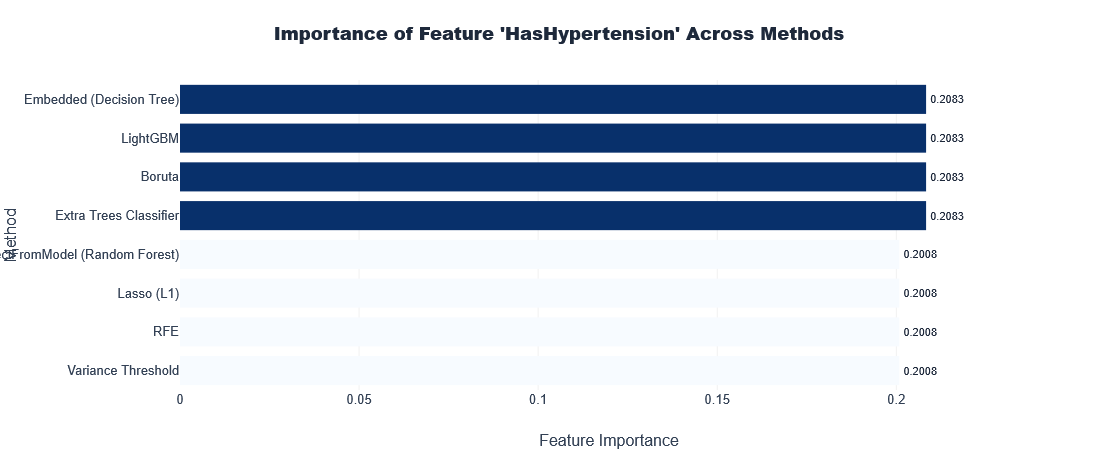

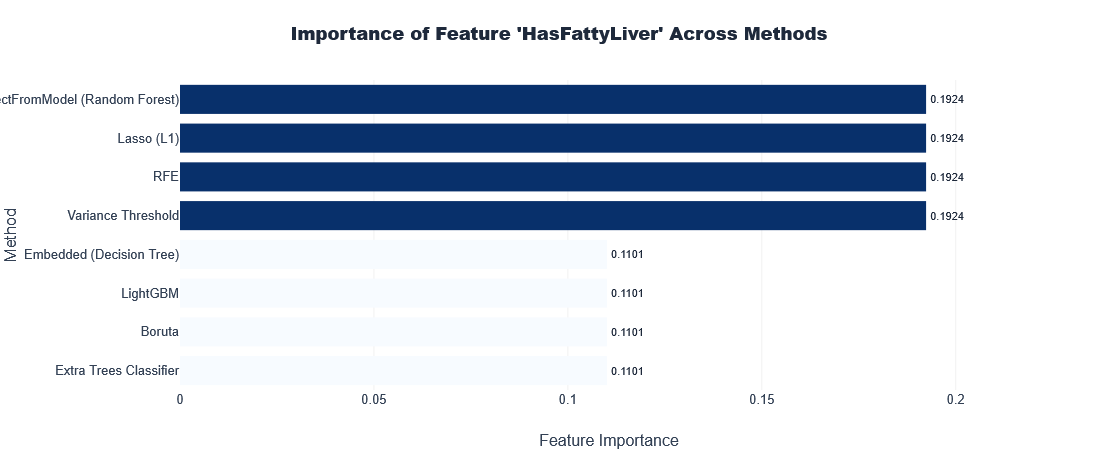

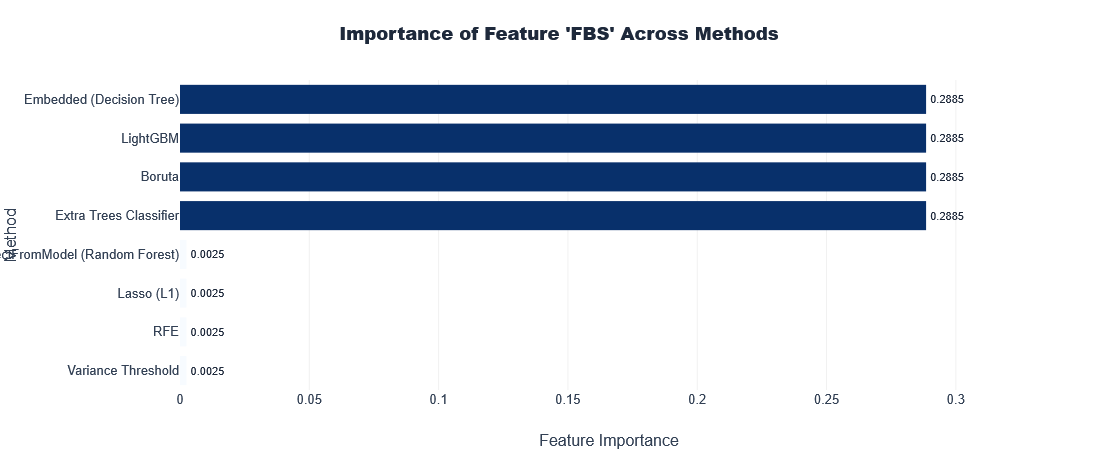

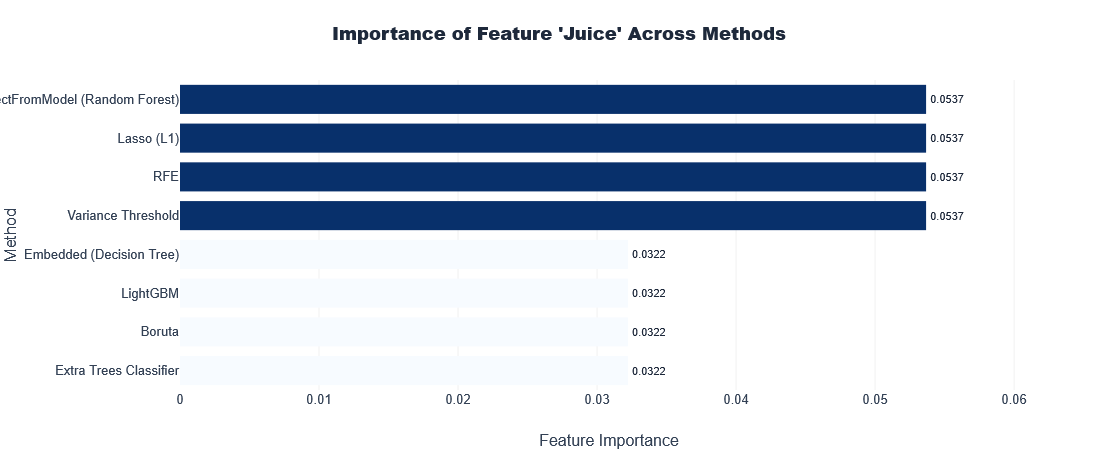

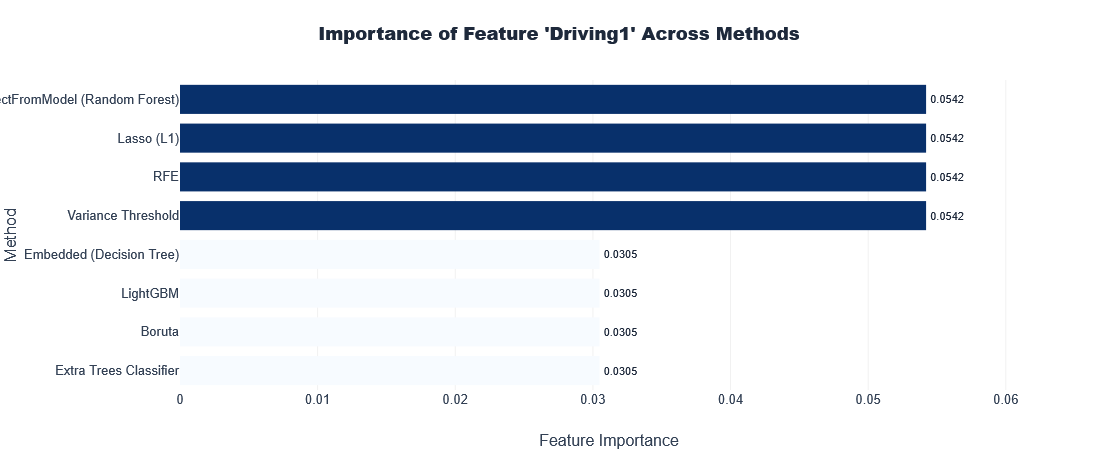

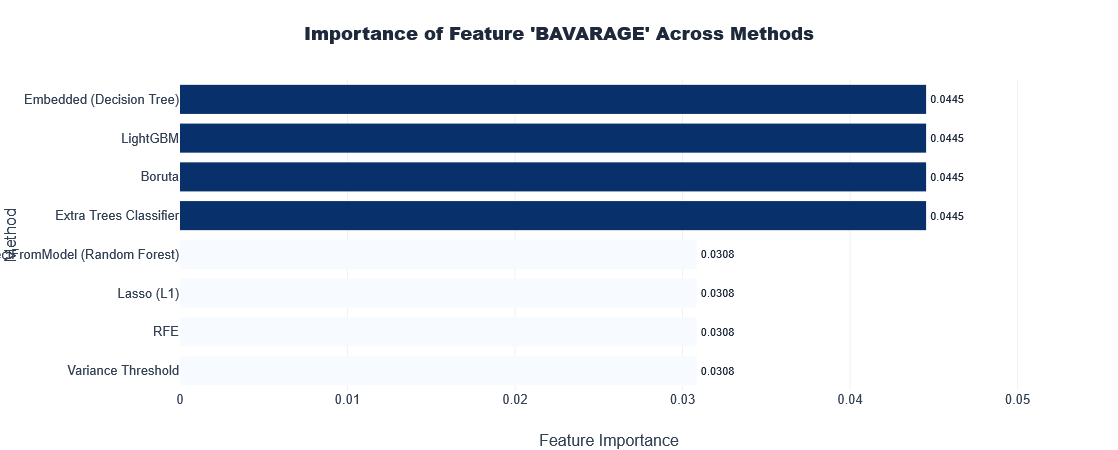

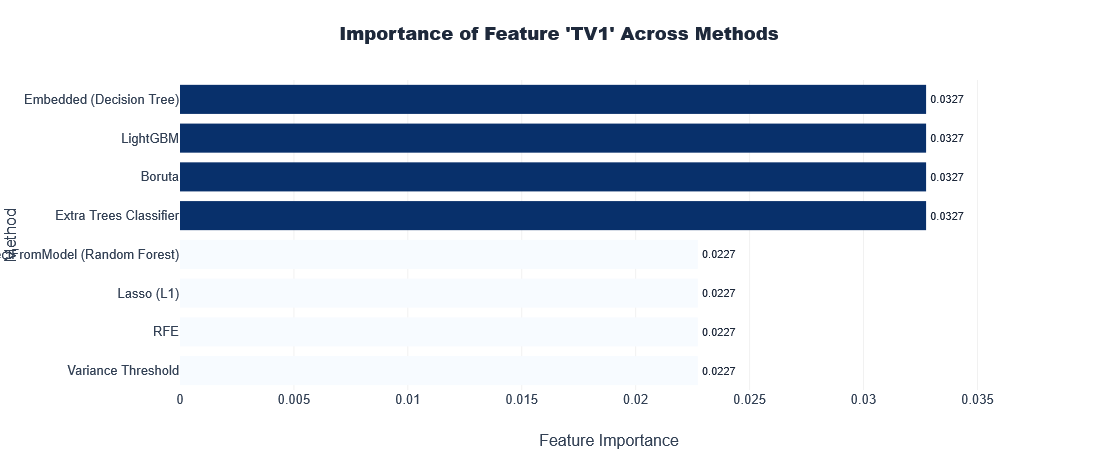

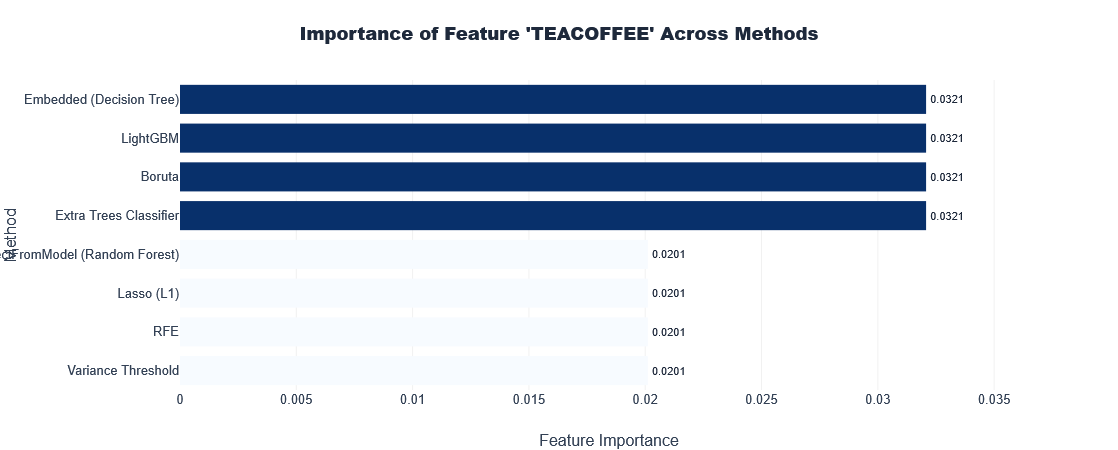

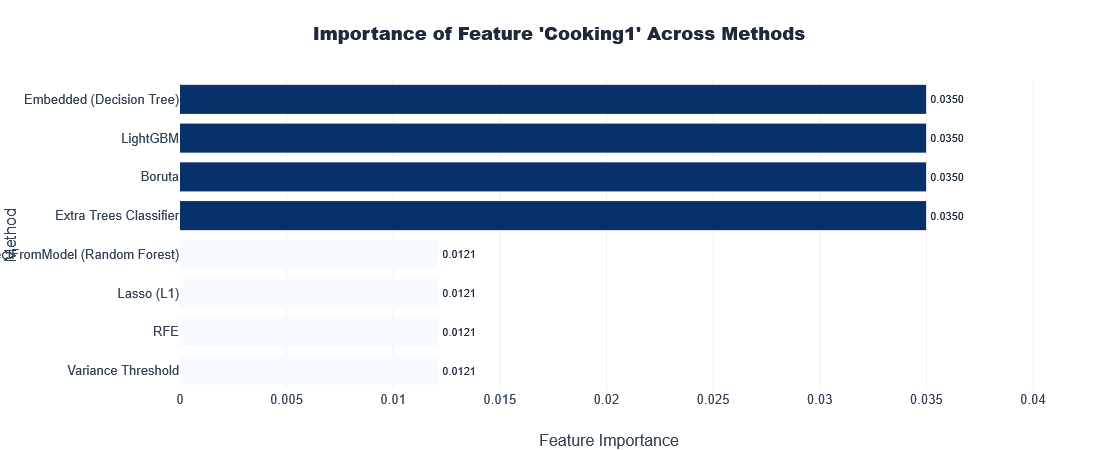

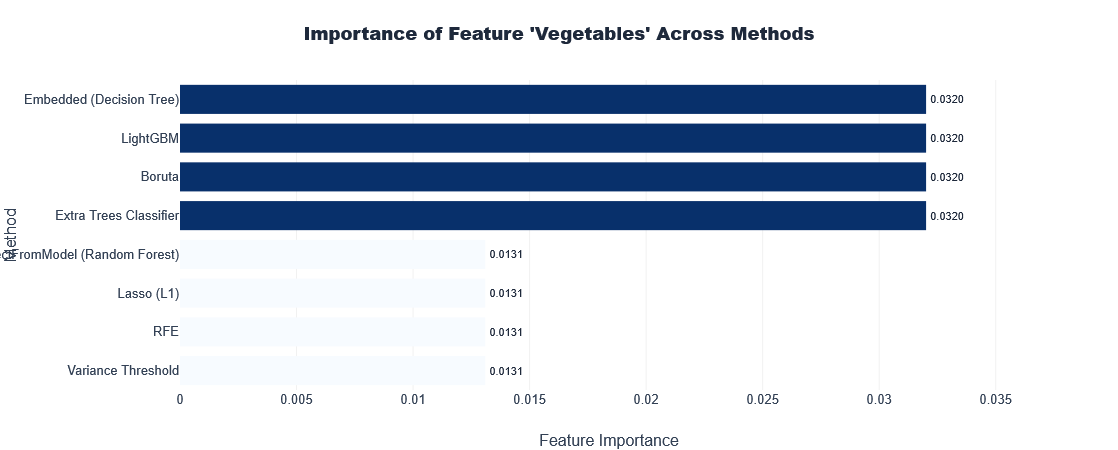

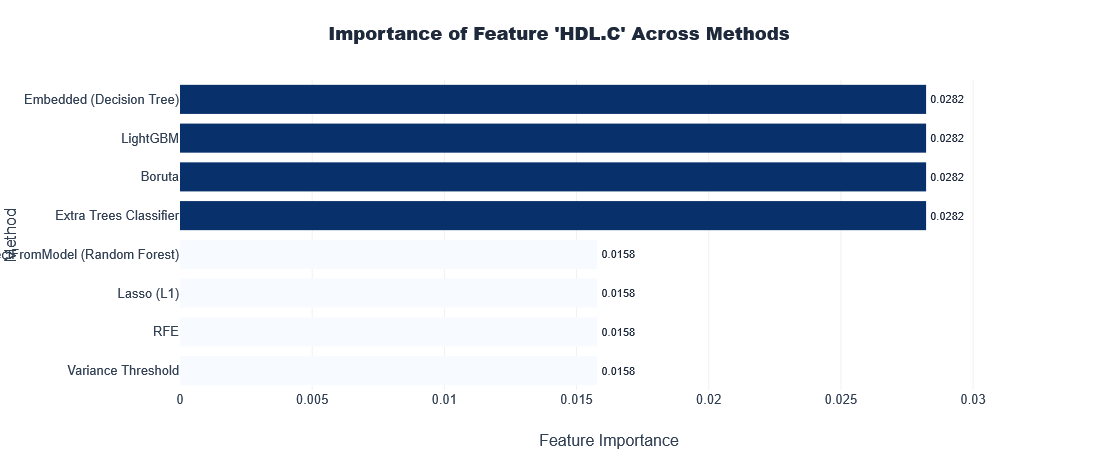

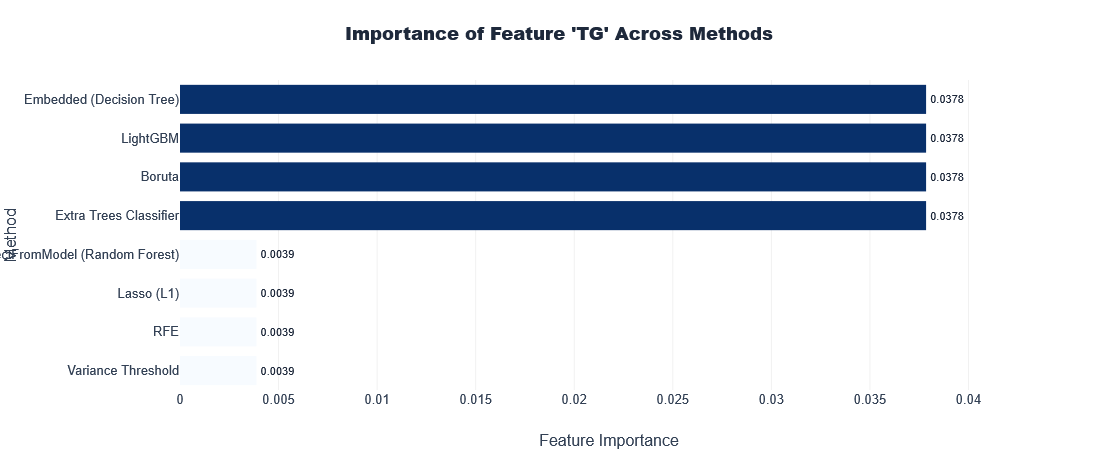

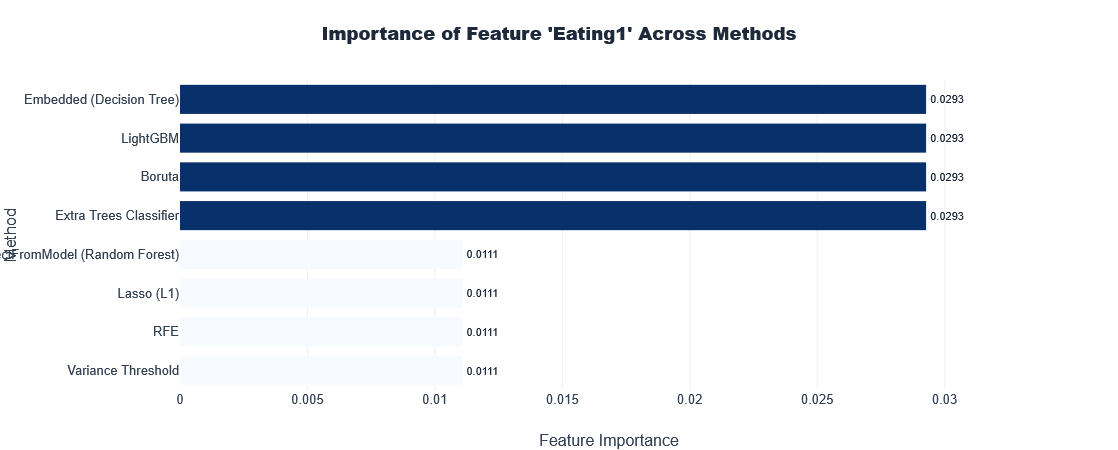

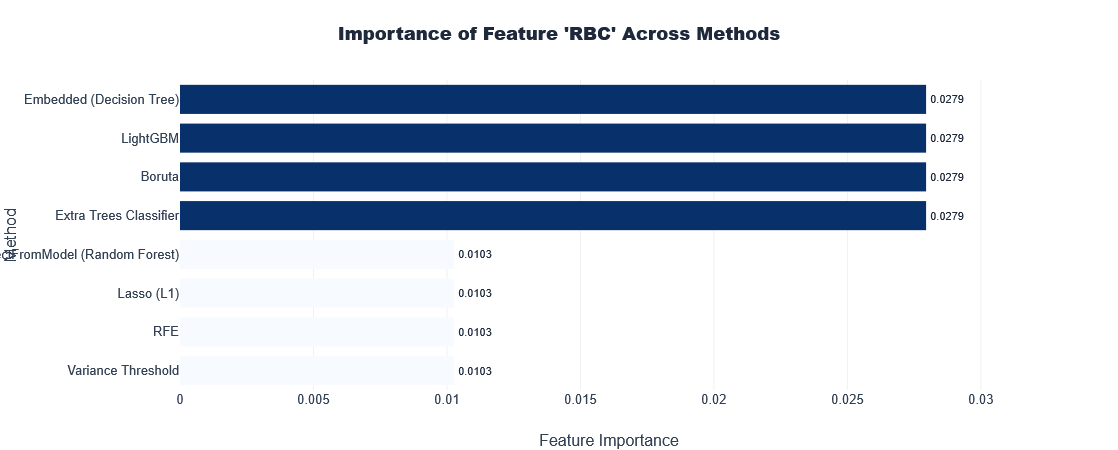

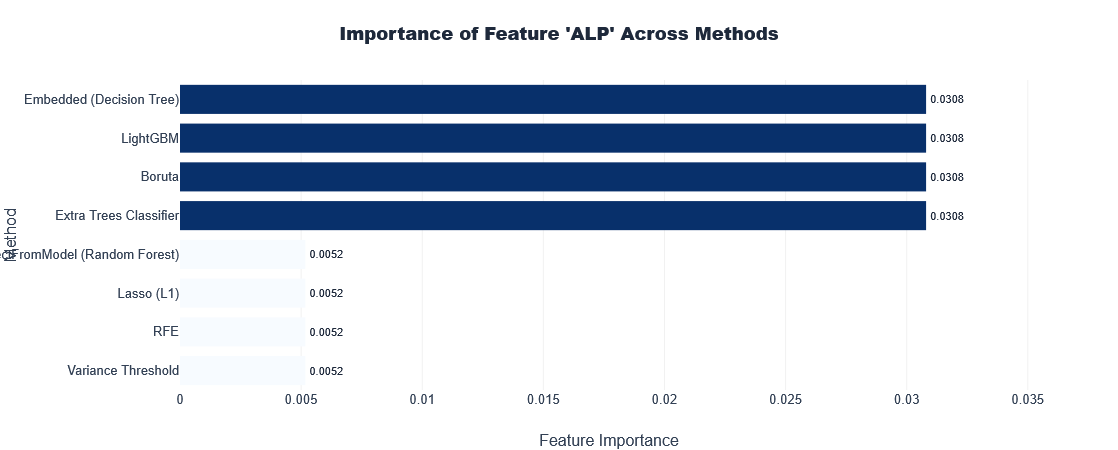

In [102]:
import os
import pandas as pd
import plotly.express as px

# --- INPUTS (you already have these) ---
# X_train: your training DataFrame
# feature_importances: dict {method_name: 1D importance array/Series}

# Convert the feature importances into a DataFrame for visualization
importance_df = pd.DataFrame(feature_importances).T  # methods in rows
importance_df.columns = X_train.columns              # use actual feature names
importance_df.columns = importance_df.columns.str.replace(r'num_imputer__', '', regex=True)

importance_df = importance_df.reset_index().rename(
    columns={'index': 'Feature Selection Method'}
)

# Determine the most important predictors (top 15 important features)
top_n = 15

# Aggregate feature importance across all methods by averaging importance scores
feature_cols = [c for c in importance_df.columns if c != 'Feature Selection Method']
importance_avg = importance_df[feature_cols].mean(axis=0)

# Get the top 15 most important features
top_features = importance_avg.nlargest(top_n).index

# Filter to only the top features
importance_top_features_df = importance_df[['Feature Selection Method'] + list(top_features)]

# Melt to long format
importance_melted = importance_top_features_df.melt(
    id_vars='Feature Selection Method',
    var_name='Feature',
    value_name='Importance'
)

# Make sure output directory exists
output_dir = "Images"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# MODERN COLOR PALETTE FOR GRADIENT
# Choose one of the following (uncomment the one you like):
# ============================================================
# MODERN_COLORS = px.colors.sequential.Blues      # Clean, professional blue gradient
# MODERN_COLORS = px.colors.sequential.Teal      # Modern teal/cyan gradient
# MODERN_COLORS = px.colors.sequential.Viridis   # Vibrant, perceptually uniform
# MODERN_COLORS = px.colors.sequential.Plasma    # Warm modern gradient
MODERN_COLORS = px.colors.sequential.Blues       # <-- I'll use this as default

# --- PLOTTING: ONE CLEAN HORIZONTAL BAR CHART PER FEATURE ---
for feature in top_features:
    # Filter data for this feature
    feature_data = importance_melted[importance_melted['Feature'] == feature].copy()

    # Sort methods by importance for this feature
    feature_data = feature_data.sort_values('Importance', ascending=True)

    title = f"Importance of Feature '{feature}' Across Methods"

    # Horizontal bar plot with color gradient based on importance
    fig = px.bar(
        feature_data,
        x='Importance',
        y='Feature Selection Method',
        orientation='h',
        title=title,
        text='Importance',
        color='Importance',                     # <-- ENABLED: creates gradient
        color_continuous_scale=MODERN_COLORS,   # <-- apply modern palette
        height=max(450, 50 * len(feature_data)) # dynamic height with extra space
    )

    # Modern, clean layout
    fig.update_layout(
        xaxis_title="Feature Importance",
        yaxis_title="Method",
        title_x=0.5,
        title_font=dict(size=18, family="Arial Black", color="#1e293b"),
        font=dict(family="Arial, sans-serif", size=13, color="#334155"),
        margin=dict(t=80, b=60, l=180, r=80),   # increased left margin for long method names
        plot_bgcolor='white',                    # pure white background
        paper_bgcolor='white',
        showlegend=False,                        # no legend needed for a single feature
        bargap=0.25,                             # thinner bars for a sleek look
        xaxis=dict(
            showgrid=True,
            gridcolor='rgba(0,0,0,0.06)',        # very subtle grid
            zeroline=False,
        ),
        yaxis=dict(
            showgrid=False,
            zeroline=False,
        ),
        coloraxis_showscale=False                # hide the color bar (not needed)
    )

    # Format text labels and add some headroom on x-axis
    max_val = feature_data['Importance'].max()
    fig.update_traces(
        texttemplate='%{text:.4f}',
        textposition='outside',
        textfont=dict(size=11, color='#1e293b')
    )
    fig.update_xaxes(range=[0, max_val * 1.15])  # 15% extra space for labels

    fig.show()

    # Safe filename
    safe_feature = (
        str(feature)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace("*", "_")
        .replace("?", "_")
        .replace('"', "'")
        .replace("<", "_")
        .replace(">", "_")
        .replace("|", "_")
    )
    filename = os.path.join(output_dir, f"importance_{safe_feature}.png")

    fig.write_image(filename, scale=6)
